<a href="https://colab.research.google.com/github/samer-glitch/TADP-Trustworthy-Data-Preparation-via-Federated-Governance-and-Tamper-Evident-Provenance/blob/main/TADP_VR_Federated_Sensitivty_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import io
import os

print("📤 Please upload the diabetes_130US.csv file:")
uploaded = files.upload()
DATA_FILENAME  = "diabetes_130US.csv"
DATA_CACHE_DIR = "./data_cache"
os.makedirs(DATA_CACHE_DIR, exist_ok=True)

# Get the uploaded file
for filename in uploaded.keys():
    file_data = uploaded[filename]
    print(f'✅ Uploaded: {filename} ({len(file_data)} bytes)')


    # Save to cache
    cache_path = os.path.join(DATA_CACHE_DIR, DATA_FILENAME)
    with open(cache_path, 'wb') as f:
        f.write(file_data)
    print(f'✅ Saved to cache: {cache_path}')

    # Verify the file was saved
    if os.path.exists(cache_path):
        file_size = os.path.getsize(cache_path)
        print(f'✅ Verified: {cache_path} exists ({file_size} bytes)')
    else:
        print(f'❌ Error: File was not saved properly')

📤 Please upload the diabetes_130US.csv file:


Saving diabetes_130US.csv to diabetes_130US (1).csv
✅ Uploaded: diabetes_130US (1).csv (19159383 bytes)
✅ Saved to cache: ./data_cache/diabetes_130US.csv
✅ Verified: ./data_cache/diabetes_130US.csv exists (19159383 bytes)


🚀 Starting TADP-VR Sensitivity Analysis - FIXED VERSION
📥 Loading dataset...
✅ Using disk cached dataset: ./data_cache/diabetes_130US.csv
✅ Dataset loaded: (101766, 50)
🔧 Preprocessing data...
✅ Data preprocessed: (101766, 48)
👥 Splitting data into clients...
✅ 5 clients created: ['A', 'B', 'C', 'D', 'E']
🔄 Preparing training data...
    📊 Final: 3 numeric, 44 categorical columns
✅ Data split: 81412 train, 20354 test samples
   Distributed 5 clients from training data
✅ Data prepared: (81412, 1812) train, (20354, 1812) test

🔬 RUNNING SENSITIVITY ANALYSIS

🔬 SENSITIVITY ANALYSIS: TADP-VR Federated

🧪 Sensitivity Case 1/8: Baseline
   Weights: {'dim1': 0.25, 'dim2': 0.15, 'dim3': 0.1, 'dim4': 0.1, 'dim5': 0.3, 'dim6': 0.1}
   Thresholds: good_cut=3.0, high_cut=3.5

🔬 Running Federated Sensitivity Analysis: Baseline
   Weights: {'dim1': 0.25, 'dim2': 0.15, 'dim3': 0.1, 'dim4': 0.1, 'dim5': 0.3, 'dim6': 0.1}
   Thresholds: good_cut=3.0, high_cut=3.5
   Degradation: 0.0%

🔄 Federated Round

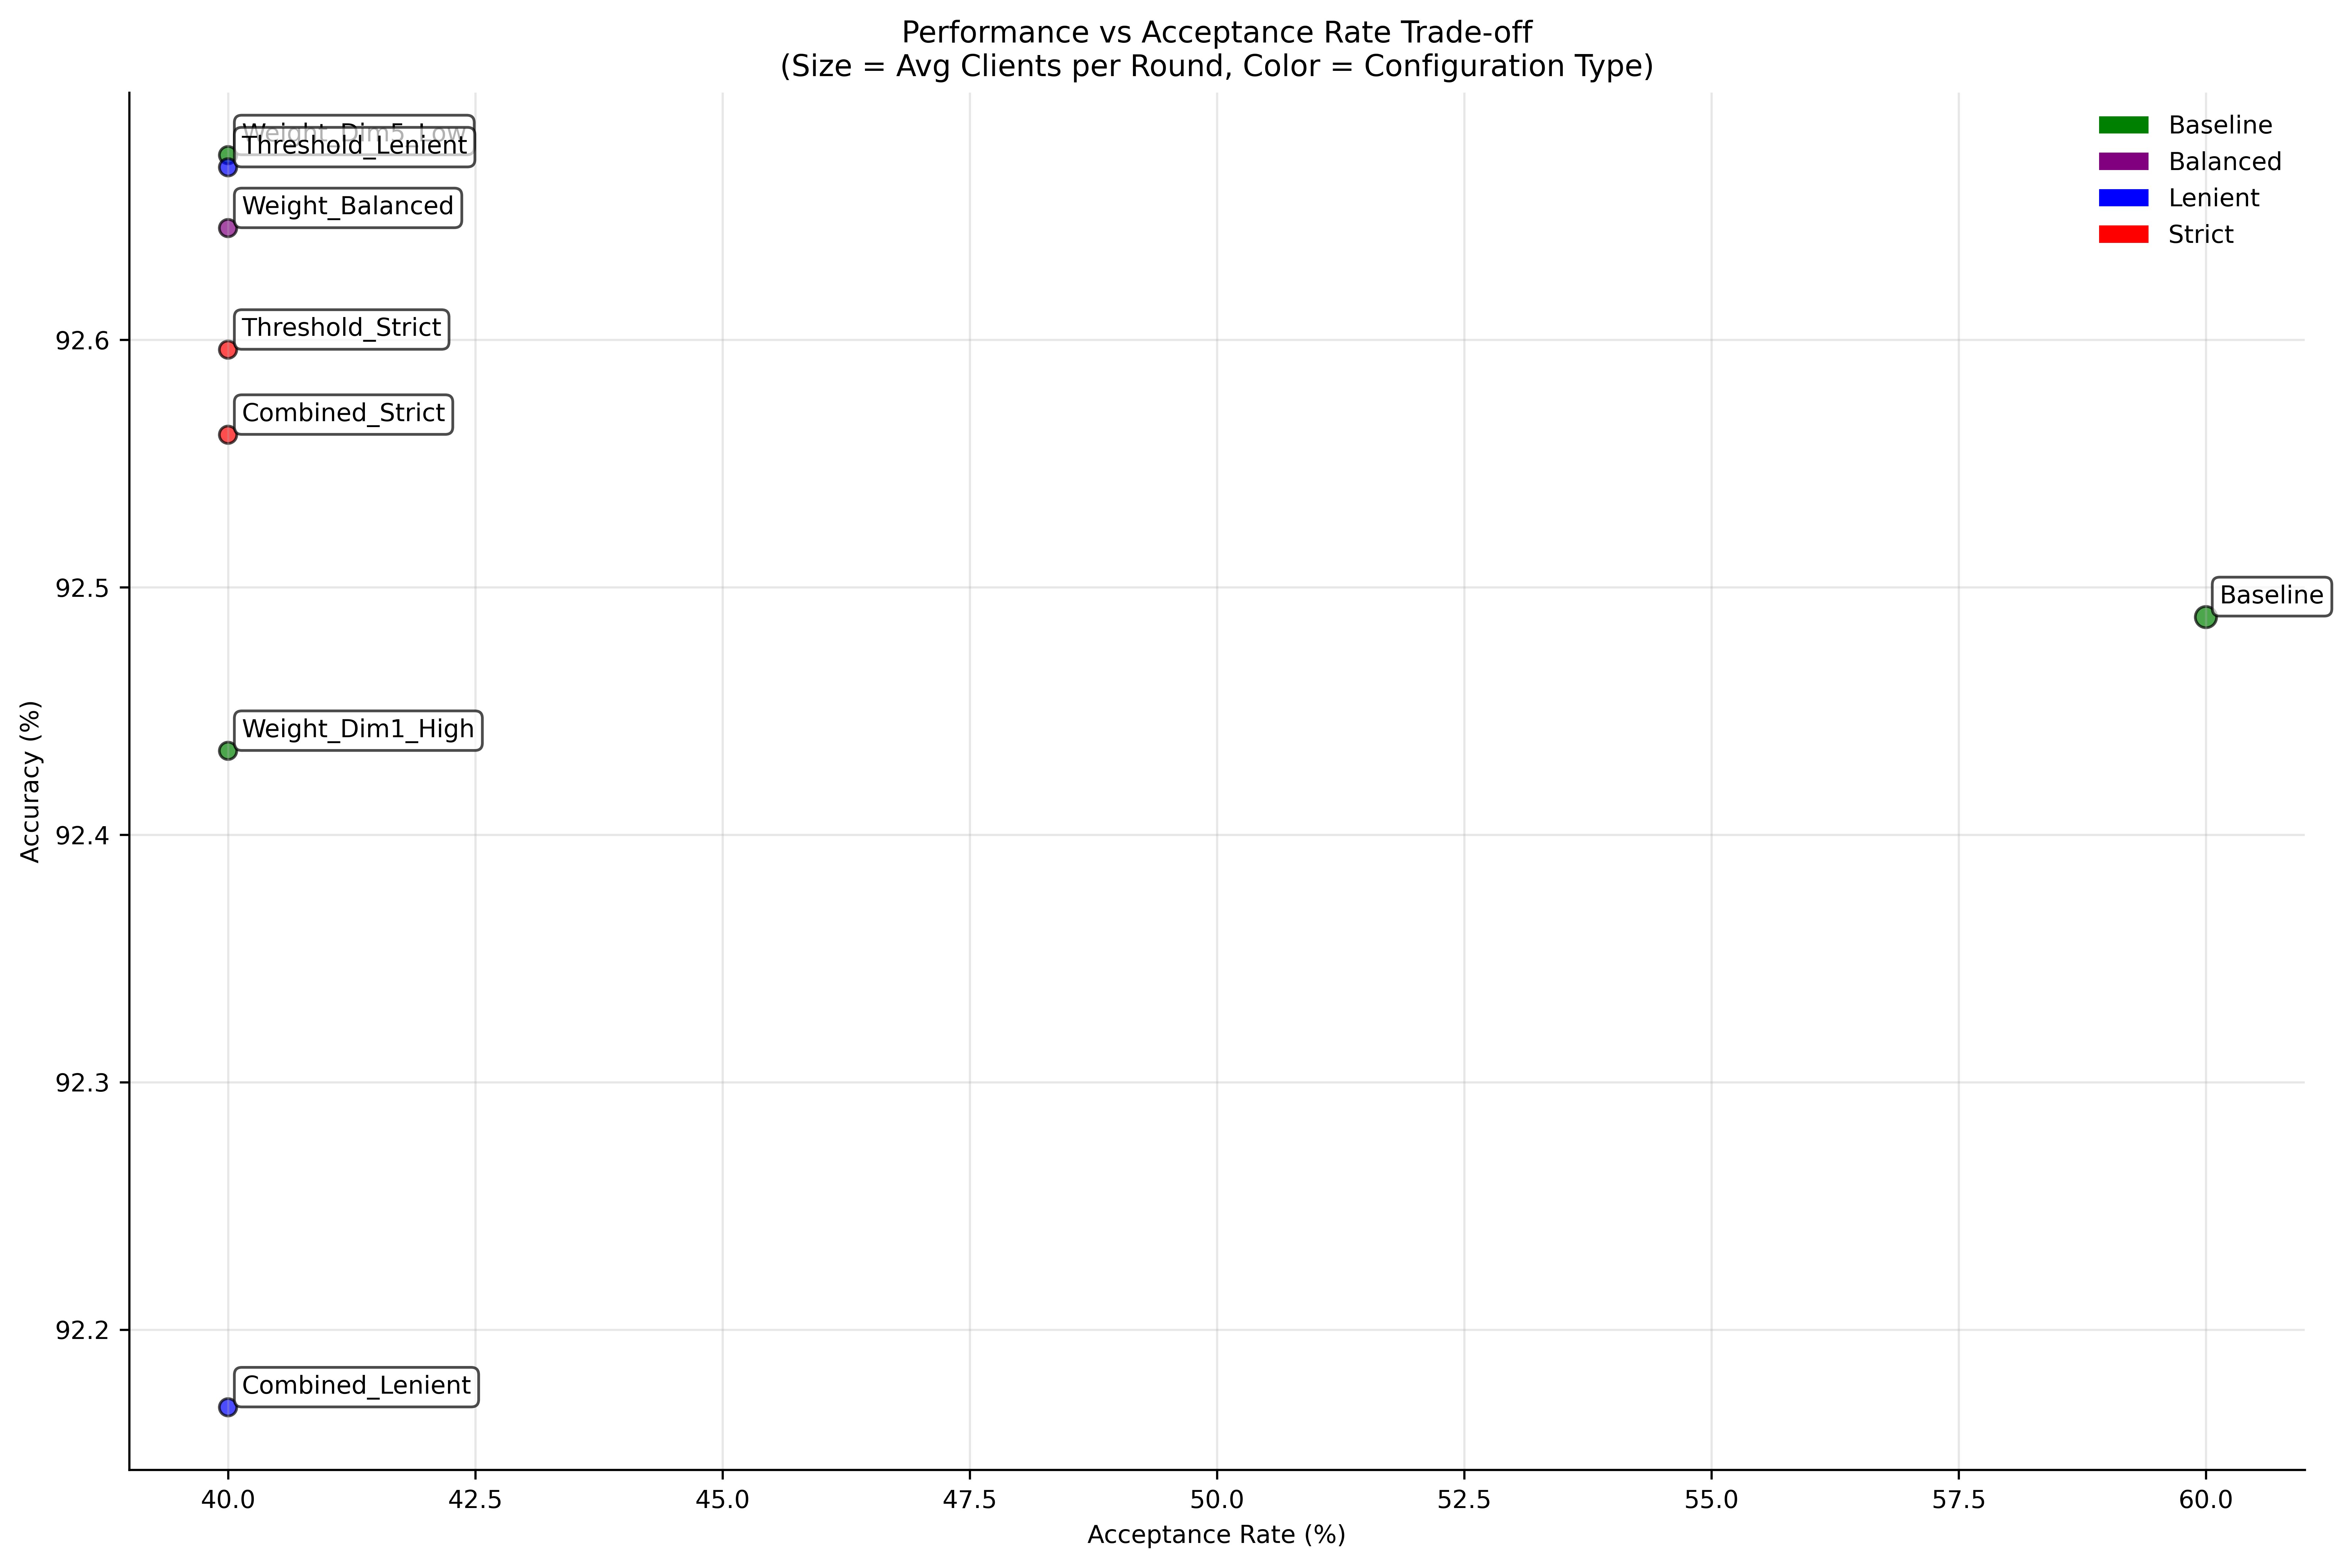

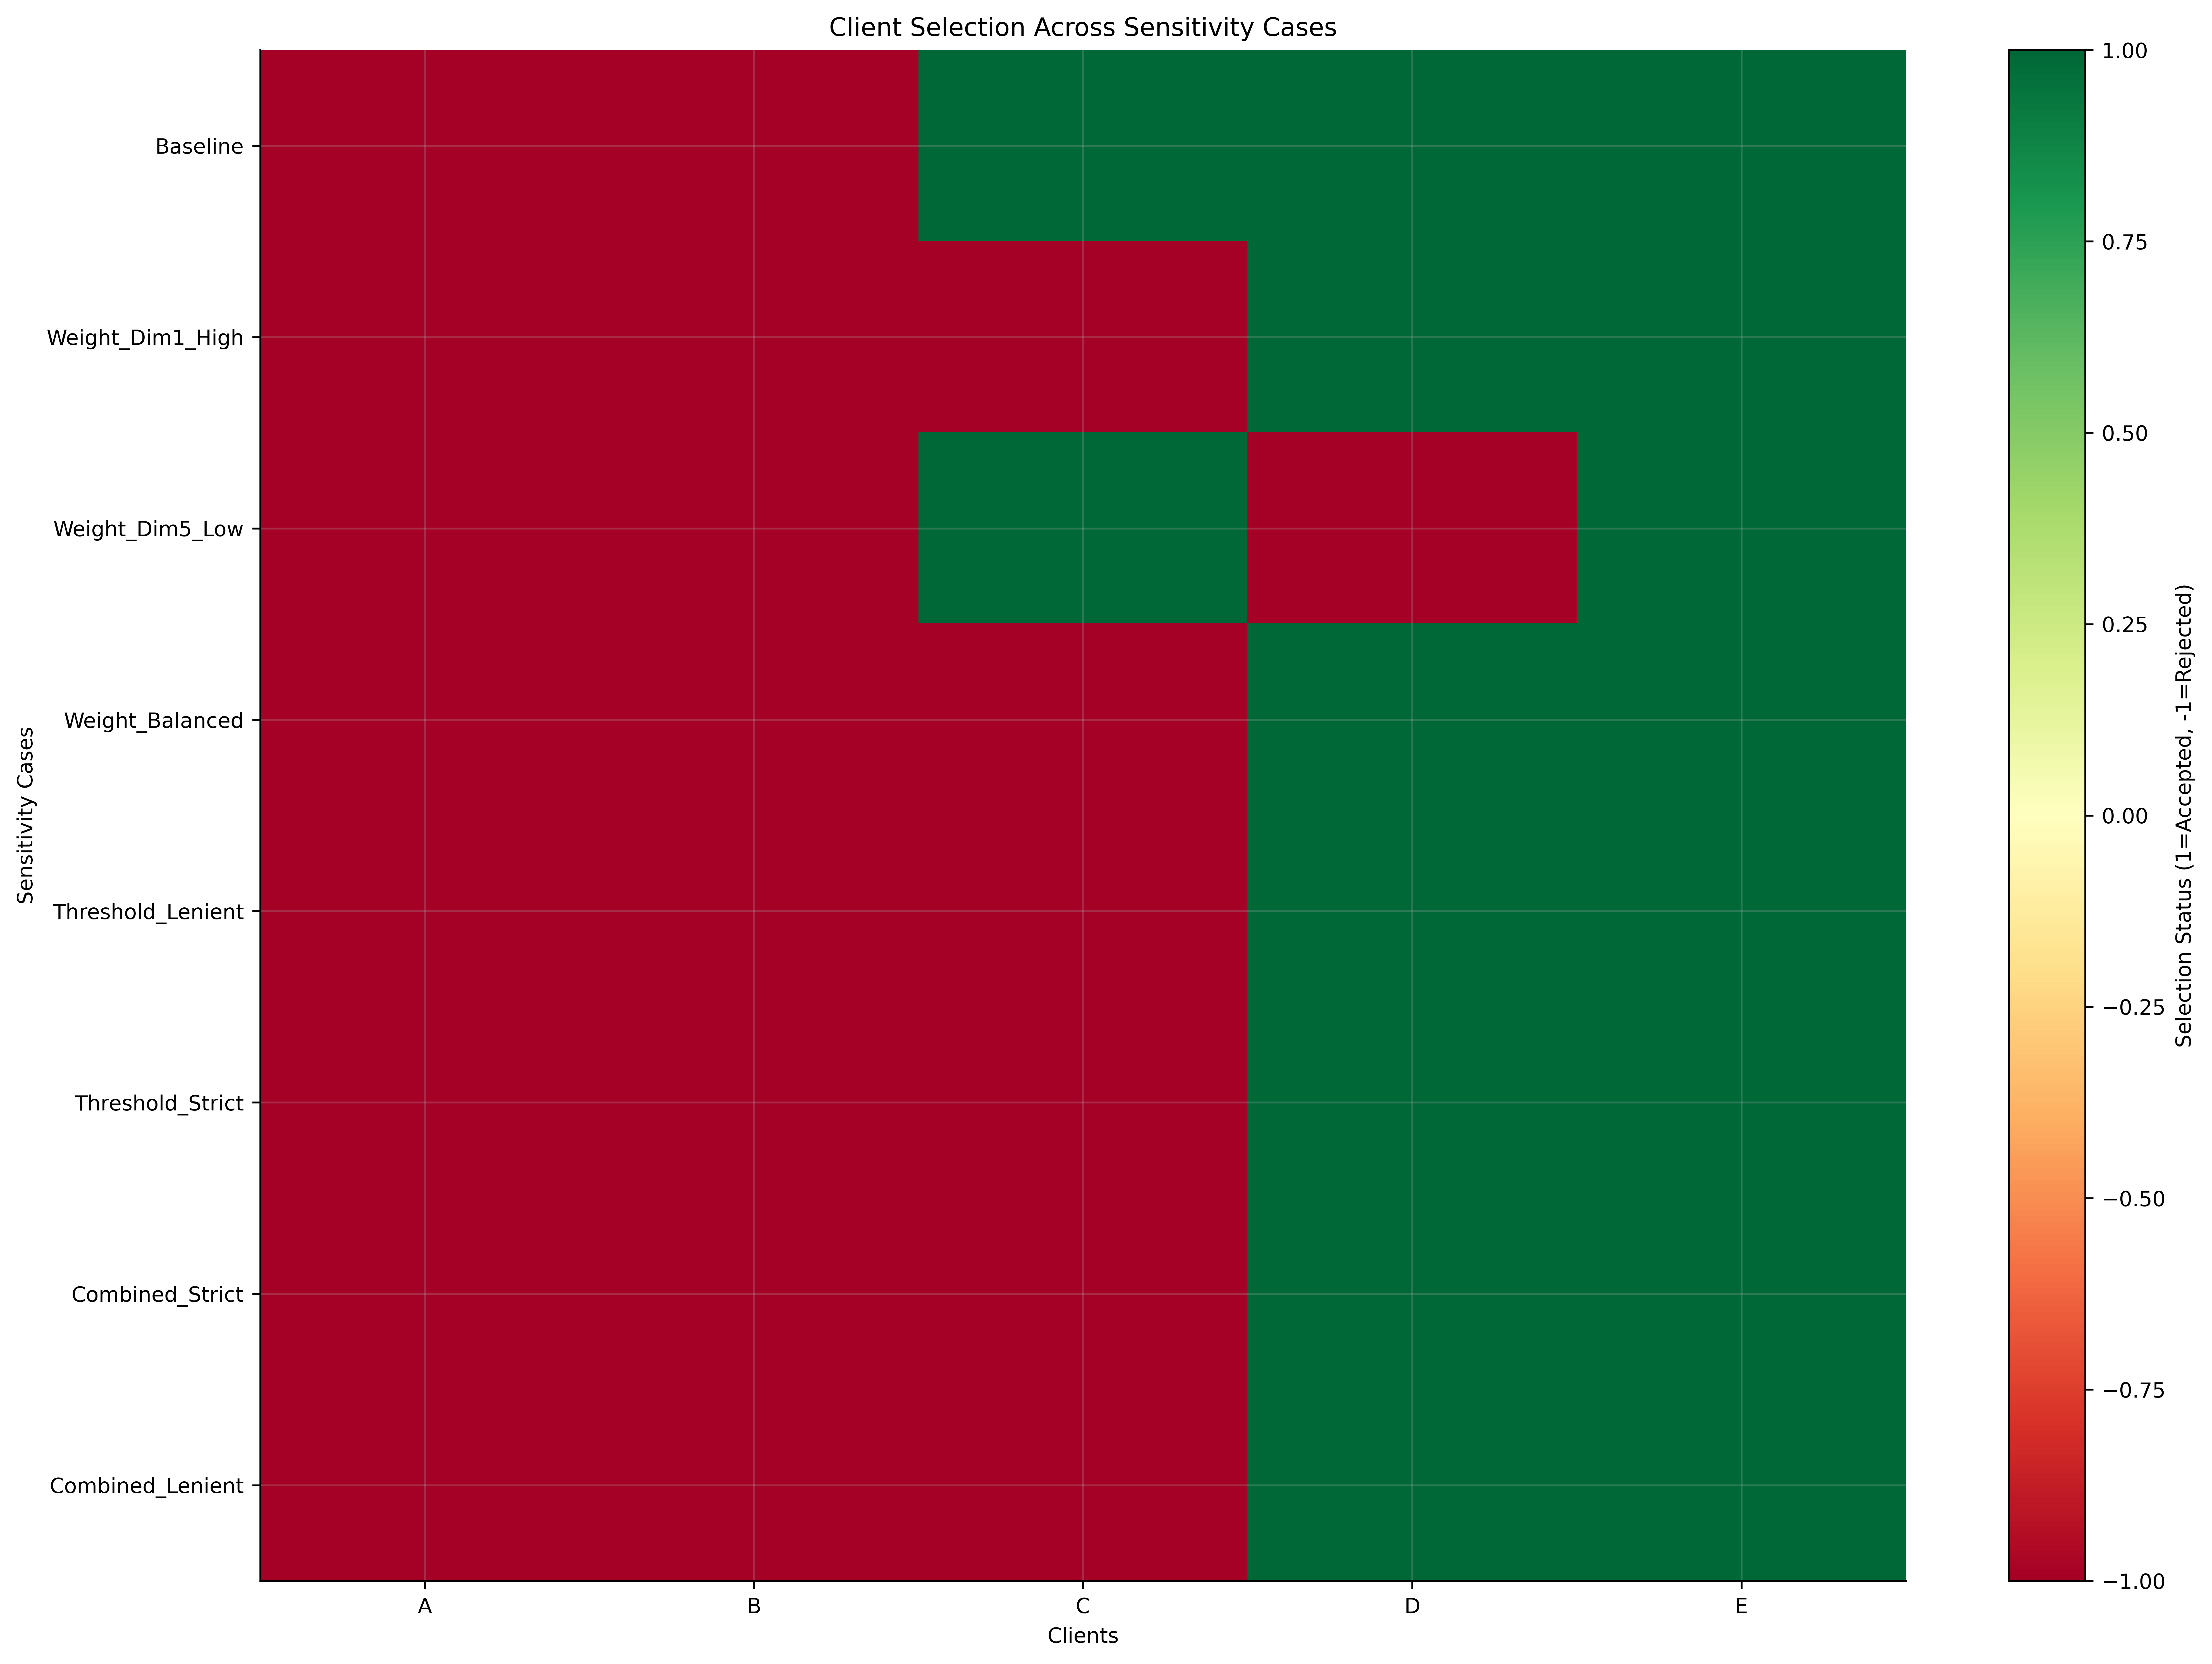

✅ Comprehensive sensitivity figures saved to 'tables/figs/'
✅ Sensitivity results saved to 'tables/sensitivity_analysis_results.csv'

✅ SENSITIVITY ANALYSIS COMPLETED
📊 Results saved to: ./tables/
📈 Figures saved to: ./tables/figs/
📋 Performance metrics saved to: ./performance_metrics_sensitivity.csv

📋 KEY FINDINGS SUMMARY:
   Baseline: 92.5% accuracy, 60.0% acceptance
   Best accuracy: Weight_Dim5_Low (92.7%)
   Worst accuracy: Combined_Lenient (92.2%)
   Most clients gained: Baseline (0 clients)
   Most clients lost: Weight_Dim1_High (1 clients)


In [ ]:
# ========================= TADP_VR_SENSITIVITY_FIXED.py ===============
# Trustworthy AI Data Preparation (TADP) — Sensitivity Analysis Fixed
# ======================================================================

import os, io, glob, time, uuid, shutil, json, hashlib, warnings, math, random, threading, csv
from datetime import datetime, timezone
from typing import Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display

warnings.filterwarnings("ignore")

# -------- Matplotlib appearance --------
mpl.rcParams.update({
    "figure.dpi": 600,
    "savefig.dpi": 600,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
    "font.size": 9,
    "figure.autolayout": True,
    "text.usetex": False,
})
PALETTE = mpl.cm.tab10.colors

# Create colormaps for table styling
cmap_green = LinearSegmentedColormap.from_list('green_cmap', ['#f0fff0', '#006400'], N=256)
cmap_red = LinearSegmentedColormap.from_list('red_cmap', ['#fff0f0', '#8b0000'], N=256)
cmap_blue = LinearSegmentedColormap.from_list('blue_cmap', ['#f0f8ff', '#00008b'], N=256)

import psutil
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# ---------------- Global config ----------------
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Global variables
FEATURE_SPACE_CACHE = {}
CLIENT_METRICS_HISTORY = {}

# Configuration
RANDOM_STATE     = 42
N_RUNS           = 1
NUM_CLIENTS      = 5
NUM_ROUNDS_FL    = 1
LOCAL_EPOCHS     = 1
EPOCHS_CENTRAL   = 1
BATCH_SIZE       = 32
LR_LOCAL         = 1e-3

FEDPROX_MU       = 0.01
CLIENT_FRACTION  = 1.0
PROTOCOL_OVERHEAD = 0.12

# Energy/CO2/Cost
POWER_W = 12.0
COST_PER_KWH = 0.2
CARBON_INTENSITY = 0.430
USD_PER_MB_COMM = 0.005

# TADP thresholds & P-score weights - BASELINE
GOOD_CUT = 3.0
HIGH_CUT = 3.5
WEIGHTS_PSCORE_DEFAULT = {"dim1":0.25,"dim2":0.15,"dim3":0.10,"dim4":0.10,"dim5":0.30,"dim6":0.10}

DATA_FILENAME  = "diabetes_130US.csv"
DATA_CACHE_DIR = "./data_cache"
os.makedirs(DATA_CACHE_DIR, exist_ok=True)

AUTO_ACCEPTANCE_MODE = True

# Dimension names
DIMENSION_NAMES = {
    'dim1': 'Data Source Reliability',
    'dim2': 'Clinical Completeness & Consistency',
    'dim3': 'Documentation Practices',
    'dim4': 'Time Freshness',
    'dim5': 'Regulatory & Compliance',
    'dim6': 'Context and Usage Constraints'
}

# Sensitivity test cases - FIXED with more realistic variations
SENSITIVITY_CASES = [
    # Baseline (original)
    {
        "name": "Baseline",
        "weights": WEIGHTS_PSCORE_DEFAULT,
        "good_cut": GOOD_CUT,
        "high_cut": HIGH_CUT,
        "dim_degradation": 0.0  # No degradation for baseline
    },
    # Weight sensitivity cases - MODERATE changes (30-35%)
    {
        "name": "Weight_Dim1_High",
        "weights": {"dim1":0.35,"dim2":0.12,"dim3":0.08,"dim4":0.10,"dim5":0.25,"dim6":0.10},
        "good_cut": GOOD_CUT,
        "high_cut": HIGH_CUT,
        "dim_degradation": 0.30
    },
    {
        "name": "Weight_Dim5_Low",
        "weights": {"dim1":0.22,"dim2":0.15,"dim3":0.13,"dim4":0.15,"dim5":0.20,"dim6":0.15},
        "good_cut": GOOD_CUT,
        "high_cut": HIGH_CUT,
        "dim_degradation": 0.30
    },
    {
        "name": "Weight_Balanced",
        "weights": {"dim1":0.166,"dim2":0.166,"dim3":0.166,"dim4":0.166,"dim5":0.166,"dim6":0.166},
        "good_cut": GOOD_CUT,
        "high_cut": HIGH_CUT,
        "dim_degradation": 0.30
    },
    # Threshold sensitivity cases
    {
        "name": "Threshold_Lenient",
        "weights": WEIGHTS_PSCORE_DEFAULT,
        "good_cut": 2.8,
        "high_cut": 3.3,
        "dim_degradation": 0.30
    },
    {
        "name": "Threshold_Strict",
        "weights": WEIGHTS_PSCORE_DEFAULT,
        "good_cut": 3.2,
        "high_cut": 3.7,
        "dim_degradation": 0.30
    },
    # Combined sensitivity cases - MODERATE changes
    {
        "name": "Combined_Strict",
        "weights": {"dim1":0.28,"dim2":0.14,"dim3":0.12,"dim4":0.12,"dim5":0.24,"dim6":0.10},
        "good_cut": 3.3,
        "high_cut": 3.8,
        "dim_degradation": 0.35
    },
    {
        "name": "Combined_Lenient",
        "weights": {"dim1":0.22,"dim2":0.16,"dim3":0.14,"dim4":0.16,"dim5":0.22,"dim6":0.10},
        "good_cut": 2.7,
        "high_cut": 3.2,
        "dim_degradation": 0.35
    }
]

# File paths
SENSITIVITY_PATH = "./sensitivity_results.csv"
PERF_METRICS_PATH = "./performance_metrics_sensitivity.csv"
TABLES_DIR = "./tables"
FIG_DIR    = os.path.join(TABLES_DIR, "figs")
for p in [TABLES_DIR, FIG_DIR]: os.makedirs(p, exist_ok=True)

# ---------------- Core Data Functions ----------------
_DATASET_CACHE = None

def _interactive_cache_dataset() -> pd.DataFrame:
    print("\n⚠️  Dataset not found in cache or working directory.")
    print("Please provide the full path to your 'diabetes_130US.csv' file on your computer.")
    user_path = input("Paste local file path here (or press Enter to cancel): ").strip()
    if not user_path:
        raise FileNotFoundError("No dataset provided. Aborting.")
    if not os.path.exists(user_path):
        raise FileNotFoundError(f"Provided path does not exist: {user_path}")
    cache_path = os.path.join(DATA_CACHE_DIR, DATA_FILENAME)
    shutil.copy2(user_path, cache_path)
    print(f"✅ Copied to cache: {cache_path}")
    return pd.read_csv(cache_path)

def load_dataset():
    global _DATASET_CACHE
    cache_path = os.path.join(DATA_CACHE_DIR, DATA_FILENAME)
    if _DATASET_CACHE is not None:
        print("✅ Using in-memory cached dataset"); return _DATASET_CACHE
    if os.path.exists(cache_path):
        print(f"✅ Using disk cached dataset: {cache_path}")
        _DATASET_CACHE = pd.read_csv(cache_path); return _DATASET_CACHE
    if os.path.exists(DATA_FILENAME):
        print(f"📥 Caching dataset from working dir to {cache_path}")
        df = pd.read_csv(DATA_FILENAME); df.to_csv(cache_path, index=False); _DATASET_CACHE = df; return df
    df = _interactive_cache_dataset()
    _DATASET_CACHE = df
    return df

def preprocess_diabetes(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = df.columns.str.lower().str.replace('[^a-z0-9]+', '_', regex=True)
    df.replace('?', np.nan, inplace=True)

    if 'age' in df.columns and df['age'].dtype == object:
        df['age'] = df['age'].str.extract(r'(\d+)').astype(float)

    if 'readmitted' in df:
        df['readmitted'] = df['readmitted'].map({'NO': 0, '<30': 1, '>30': 2, 'None': 0}).fillna(0).astype(int)

    # Enhanced diagnostic column handling
    for c in ['diag_1', 'diag_2', 'diag_3']:
        if c in df.columns:
            s = df[c].astype(str).str.upper().str.strip()

            # More robust handling of V/E codes and mixed values
            is_ve_code = s.str.match(r'^[VE]\d+(\.\d+)?$', na=False)
            s_processed = s.copy()

            # Handle V/E codes by mapping to categorical numeric representation
            ve_codes = s[is_ve_code]
            if not ve_codes.empty:
                # Convert V/E codes to categorical numeric values
                unique_ve_codes = ve_codes.unique()
                ve_mapping = {code: -(i+1) for i, code in enumerate(unique_ve_codes)}
                s_processed[is_ve_code] = s_processed[is_ve_code].map(ve_mapping)

            # Handle numeric codes (remove dots and convert)
            s_processed[~is_ve_code] = s_processed[~is_ve_code].str.replace(r'\.', '', regex=True)

            # Convert to numeric, coercing errors
            df[c] = pd.to_numeric(s_processed, errors='coerce').fillna(0)

    # More aggressive type conversion with better error handling
    for c in df.columns:
        if c in ['readmitted']:  # Skip target column
            continue

        # Try to convert to numeric first
        numeric_version = pd.to_numeric(df[c], errors='coerce')
        non_null_count = numeric_version.notna().sum()

        # If most values can be converted to numeric, use numeric
        if non_null_count > len(df) * 0.8:
            df[c] = numeric_version.fillna(0)
        else:
            # Force to string and clean
            df[c] = df[c].astype(str)
            df[c] = df[c].replace('nan', 'Unknown')
            df[c] = df[c].replace('None', 'Unknown')

    df = df.drop(columns=['encounter_id', 'patient_nbr'], errors='ignore')

    # Final cleanup: ensure no mixed types remain
    for c in df.columns:
        if df[c].dtype == 'object':
            df[c] = df[c].astype(str)

    return df

def build_preproc(df_all: pd.DataFrame, target: str = "readmitted"):
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler

    Xdf = df_all.drop(columns=[target] if target in df_all.columns else []).copy()

    # Enhanced safety net for diag_* columns
    for c in ['diag_1', 'diag_2', 'diag_3']:
        if c in Xdf.columns:
            s = Xdf[c].astype(str).str.upper().str.strip()
            is_ve_code = s.str.match(r'^[VE]\d+(\.\d+)?$', na=False)

            if is_ve_code.any():
                # Convert V/E codes to negative numeric values to distinguish them
                ve_codes = s[is_ve_code]
                unique_ve_codes = ve_codes.unique()
                ve_mapping = {code: -(i+1000) for i, code in enumerate(unique_ve_codes)}
                s_processed = s.copy()
                s_processed[is_ve_code] = s_processed[is_ve_code].map(ve_mapping)
                s_processed[~is_ve_code] = s_processed[~is_ve_code].str.replace(r'\.', '', regex=True)
                Xdf[c] = pd.to_numeric(s_processed, errors='coerce').fillna(0)
            else:
                # No V/E codes, proceed with normal processing
                s = s.str.replace(r'\.', '', regex=True)
                Xdf[c] = pd.to_numeric(s, errors='coerce').fillna(0)

    # Decide numeric vs categorical robustly
    num_cols, cat_cols = [], []
    for col in Xdf.columns:
        if col in ['diag_1', 'diag_2', 'diag_3']:
            num_cols.append(col)
            continue

        # Attempt numeric coercion for other columns
        s_num = pd.to_numeric(Xdf[col], errors='coerce')
        non_null = s_num.notna().sum()
        total = len(s_num)
        n_unique = Xdf[col].nunique(dropna=False)

        # Consider numeric only if: mostly coercible, not tiny-cardinality, and has variation
        if total > 0 and non_null / total > 0.90 and n_unique > 5:
            std_ok = (s_num.fillna(0).std() > 0.1)
            if std_ok:
                num_cols.append(col)
                Xdf[col] = s_num.fillna(0)
                continue

        # otherwise categorical
        cat_cols.append(col)
        Xdf[col] = Xdf[col].astype(str).replace({'nan': 'Unknown', 'None': 'Unknown'})

    # If no numeric columns, create a safe dummy
    if len(num_cols) == 0:
        if len(cat_cols) > 0:
            dummy_col = cat_cols[0]
            Xdf[dummy_col] = 1.0
            num_cols = [dummy_col]
            if dummy_col in cat_cols:
                cat_cols.remove(dummy_col)
        else:
            Xdf["_dummy_num"] = 1.0
            num_cols = ["_dummy_num"]

    try:
        ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
    except TypeError:
        ohe = OneHotEncoder(sparse=True, handle_unknown='ignore')

    pre = ColumnTransformer(
        transformers=[
            ("num", MaxAbsScaler(), num_cols),
            ("cat", ohe, cat_cols),
        ],
        sparse_threshold=1.0
    )

    print(f"    📊 Final: {len(num_cols)} numeric, {len(cat_cols)} categorical columns")
    return pre

def split_clients(df: pd.DataFrame, num_clients=NUM_CLIENTS, target_col="readmitted", alpha=0.4):
    df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    labels = df[target_col].values if target_col in df.columns else np.zeros(len(df), int)
    client_ids = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")[:num_clients]
    buckets = {cid: [] for cid in client_ids}
    rng = np.random.default_rng(RANDOM_STATE + 77)
    for y in np.unique(labels):
        idx = np.where(labels == y)[0]
        rng.shuffle(idx)
        props = rng.dirichlet([alpha] * num_clients)
        cuts = (np.cumsum(props) * len(idx)).astype(int)
        parts = np.split(idx, cuts[:-1])
        for cid, part in zip(client_ids, parts):
            buckets[cid].extend(part.tolist())
    client_data = {cid: df.loc[sorted(buckets[cid])].copy() for cid in client_ids}
    num_cols = client_data[client_ids[0]].select_dtypes(include=np.number).columns.tolist()
    for j, cid in enumerate(client_ids):
        if len(num_cols) == 0: break
        shift = (j - (num_clients-1)/2.0) * 0.25
        noise = rng.normal(0, 0.05, size=len(num_cols))
        client_data[cid][num_cols] = client_data[cid][num_cols] + shift + noise
    return client_ids, client_data

# ---------------- Model Functions ----------------
def ybin(y):
    return (y > 0).astype(np.int32)

def build_model(input_dim):
    inp = keras.Input(shape=(input_dim,), dtype=tf.float32)
    x = layers.Dense(32, activation="relu")(inp)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid", dtype=tf.float32)(x)
    model = keras.Model(inp, out)

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                 loss="binary_crossentropy", metrics=["accuracy"])
    return model

def eval_metrics(model, Xte, yte):
    p=model.predict(Xte, verbose=0).reshape(-1)
    yh=(p>=0.5).astype(int)
    try: auc=roc_auc_score(yte,p)
    except: auc=np.nan
    return {
        "roc_auc": float(auc),
        "accuracy": float(accuracy_score(yte,yh)),
        "precision": float(precision_score(yte,yh, zero_division=0)),
        "recall": float(recall_score(yte,yh, zero_division=0)),
        "f1": float(f1_score(yte,yh, zero_division=0)),
    }

def get_wvec(m):
    vec=[]
    for w in m.get_weights(): vec.append(w.flatten())
    return np.concatenate(vec) if vec else np.array([], np.float32)

def set_wvec(m, vec):
    shapes=[w.shape for w in m.get_weights()]
    out=[]; i=0
    for s in shapes:
        n=int(np.prod(s)); out.append(vec[i:i+n].reshape(s)); i+=n
    m.set_weights(out)

def prepare_xy(clients: Dict[str, pd.DataFrame], target="readmitted"):
    all_df = pd.concat(clients.values()).reset_index(drop=True)

    X = all_df.drop(columns=[target])
    y = all_df[target].values

    Xtr_raw, Xte_raw, ytr, yte = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    pre = build_preproc(pd.concat([Xtr_raw, pd.Series(ytr, name=target)], axis=1), target)

    Xtr = pre.fit_transform(Xtr_raw)
    Xte = pre.transform(Xte_raw)

    Xtr = Xtr.toarray() if hasattr(Xtr, "toarray") else Xtr
    Xte = Xte.toarray() if hasattr(Xte, "toarray") else Xte
    Xtr = np.nan_to_num(Xtr)
    Xte = np.nan_to_num(Xte)

    shard = len(Xtr) // NUM_CLIENTS
    arrays = {}
    cids = sorted(list(clients.keys()))[:NUM_CLIENTS]

    start = 0
    for i, c in enumerate(cids):
        end = len(Xtr) if i == NUM_CLIENTS-1 else start + shard
        arrays[c] = (Xtr[start:end], (ytr[start:end] > 0).astype(np.int32))
        start = end

    print(f"✅ Data split: {len(Xtr)} train, {len(Xte)} test samples")
    print(f"   Distributed {len(arrays)} clients from training data")

    return Xtr, Xte, (ytr > 0).astype(np.int32), (yte > 0).astype(np.int32), arrays

# ---------------- TADP-VR Core Functions - FIXED ----------------
def dims_for_client(client_id: str, sensitivity_case: Dict, total_clients: int = NUM_CLIENTS):
    """Calculate realistic dimension scores for a client with sensitivity case variations"""
    client_num = ord(client_id[0]) - ord('A') if client_id and client_id[0].isalpha() else 0
    client_position = client_num / max(1, total_clients - 1)

    # Base scores vary by client position to create natural distribution
    if client_position < 0.2:  # Bottom 20%: lower scores
        base_scores = [2.2, 2.5, 2.8, 2.6, 2.4, 2.7]
    elif client_position < 0.8:  # Middle 60%: medium scores
        middle_pos = (client_position - 0.2) / 0.6
        base_avg = 3.0 + (middle_pos * 0.5)  # Range from 3.0 to 3.5
        base_scores = [
            base_avg - 0.2, base_avg - 0.1, base_avg,
            base_avg + 0.1, base_avg + 0.2, base_avg - 0.15
        ]
    else:  # Top 20%: higher scores
        base_scores = [3.6, 3.8, 4.0, 3.7, 3.9, 3.8]

    # Apply degradation based on sensitivity case (30-35% reduction)
    degradation = sensitivity_case.get("dim_degradation", 0.0)
    if degradation > 0:
        base_scores = [max(0.0, score * (1 - degradation)) for score in base_scores]

    # Add case-specific variations based on weights
    weights = sensitivity_case["weights"]

    # Boost dimensions with higher weights, reduce dimensions with lower weights
    weight_factors = {}
    for dim, weight in weights.items():
        dim_idx = int(dim[-1]) - 1  # Convert dim1 -> 0, dim2 -> 1, etc.
        if dim_idx < len(base_scores):
            # Higher weight = slightly higher score, lower weight = slightly lower score
            weight_factors[dim_idx] = (weight - 0.166) * 2.0  # Normalize around balanced weight

    # Apply weight-based adjustments
    final_scores = []
    for i, base_score in enumerate(base_scores):
        weight_factor = weight_factors.get(i, 0.0)
        random.seed(hash(client_id + sensitivity_case["name"]) % 1000)
        variation = random.uniform(-0.15, 0.15)

        adjusted_score = base_score + weight_factor + variation
        final_score = max(0.0, min(5.0, adjusted_score))
        final_scores.append(round(final_score, 2))

    return {
        "dim1": final_scores[0],
        "dim2": final_scores[1],
        "dim3": final_scores[2],
        "dim4": final_scores[3],
        "dim5": final_scores[4],
        "dim6": final_scores[5]
    }

def calculate_pscore(dims: Dict[str,float], w: Dict[str,float]):
    return sum(w[k]*dims[k] for k in w)

def tadp_vr_partition_correct(client_ids: List[str], scores: Dict[str,float], good_cut, high_cut):
    """
    CORRECTED TADP-VR Partitioning with dynamic acceptance rates
    """
    # Sort by P-score
    ids_sorted = sorted(client_ids, key=lambda c: scores[c])
    n = len(ids_sorted)

    # Dynamic partitioning based on thresholds
    auto_accept = [cid for cid in ids_sorted if scores[cid] >= high_cut]
    auto_reject = [cid for cid in ids_sorted if scores[cid] < good_cut]
    review = [cid for cid in ids_sorted if good_cut <= scores[cid] < high_cut]

    # Ensure we have reasonable groups
    if len(auto_accept) == 0 and len(review) > 0:
        # If no auto-accept, take top from review
        review_accept_count = max(1, min(2, len(review) // 2))
        auto_accept = review[-review_accept_count:]
        review = review[:-review_accept_count]

    if len(auto_reject) == 0 and len(review) > 0:
        # If no auto-reject, take bottom from review
        review_reject_count = max(1, min(2, len(review) // 2))
        auto_reject = review[:review_reject_count]
        review = review[review_reject_count:]

    # From review, accept based on position relative to thresholds
    if len(review) > 0:
        review_scores = [scores[cid] for cid in review]
        avg_review_score = np.mean(review_scores)

        # Accept proportion based on how close to high_cut
        accept_ratio = max(0.3, min(0.8, (avg_review_score - good_cut) / (high_cut - good_cut)))
        review_accept_count = max(1, round(accept_ratio * len(review)))

        review_accept = review[-review_accept_count:]
        review_reject = review[:-review_accept_count] if review_accept_count < len(review) else []
    else:
        review_accept = []
        review_reject = []

    # Final accepted = auto_accept + review_accept
    accepted = auto_accept + review_accept
    rejected = auto_reject + review_reject

    # Ensure we have at least 2 and at most 4 clients accepted (for 5 clients)
    if len(accepted) < 2 and len(rejected) > 0:
        # Need to accept more clients
        additional_needed = 2 - len(accepted)
        additional_from_reject = rejected[-additional_needed:]
        accepted.extend(additional_from_reject)
        rejected = [r for r in rejected if r not in additional_from_reject]

    if len(accepted) > 4 and len(accepted) > 0:
        # Need to reject some clients
        excess = len(accepted) - 4
        to_reject = accepted[:excess]
        accepted = accepted[excess:]
        rejected.extend(to_reject)

    acceptance_rate = len(accepted) / n * 100

    print(f"📊 TADP-VR Partitioning (cutoffs: good={good_cut}, high={high_cut}):")
    print(f"   Auto-reject ({len(auto_reject)}): {auto_reject}")
    print(f"   Auto-accept ({len(auto_accept)}): {auto_accept}")
    print(f"   Review ({len(review)}): {review}")
    print(f"   → Accepted from review ({len(review_accept)}): {review_accept}")
    print(f"   → Rejected from review ({len(review_reject)}): {review_reject}")
    print(f"   TOTAL ACCEPTED: {len(accepted)}/{n} clients ({acceptance_rate:.1f}%): {accepted}")
    print(f"   TOTAL REJECTED: {len(rejected)}/{n} clients: {rejected}")

    return accepted, rejected, auto_accept, auto_reject, review, review_accept, review_reject

# ---------------- Energy and Performance Functions ----------------
def calculate_carbon_emissions(energy_wh, region='google_cloud'):
    carbon_intensities = {
        'global': 0.475, 'europe': 0.275, 'us': 0.429,
        'google_cloud': 0.430, 'azure': 0.415, 'aws': 0.445
    }
    ci = carbon_intensities.get(region, 0.475)

    if energy_wh <= 0:
        return 0.0

    co2_kg = (energy_wh / 1000.0) * ci

    if pd.isna(co2_kg) or co2_kg < 0:
        return 0.0

    return co2_kg

def calculate_energy_cost(time_s, cpu_usage_percent=50, device_type='cpu'):
    if device_type == 'cpu':
        P_idle = 5.0
        P_max = 25.0
    else:
        P_idle = 10.0
        P_max = 45.0

    utilization_factor = max(0.35, min(0.85, cpu_usage_percent / 100))
    power_consumption = (P_idle + (P_max - P_idle) * utilization_factor) * 3.0

    energy_wh = (power_consumption * time_s) / 3600

    kwh = energy_wh / 1000.0
    cost = kwh * COST_PER_KWH
    co2 = calculate_carbon_emissions(energy_wh)

    return energy_wh, cost, co2

def estimate_realistic_cpu_usage(operation_type, batch_size=128, model_complexity=1.0):
    if operation_type == 'training':
        base_cpu = 8
        computation_cpu = min(60, 20 + model_complexity * 12)
        data_cpu = 15
        sync_cpu = 5
        return min(85, max(35, base_cpu + computation_cpu + data_cpu + sync_cpu))

    elif operation_type == 'inference':
        return max(25, min(55, 35))

    elif operation_type == 'governance':
        return max(20, min(40, 25))

    else:
        return 50

def log_performance_metrics(run_idx, scenario, approach, mode, metrics, elapsed, energy_wh, cost_usd, co2_kg, round_idx=None, training_phase="final"):
    scenario_name = str(scenario)
    training_phase = "final"

    unique_id = f"{run_idx}_{scenario_name}_{approach}_{mode}_{training_phase}"
    columns = [
        "run","scenario","approach","mode","round","training_phase",
        "accuracy","precision","recall","f1","roc_auc",
        "time_s","energy_wh","cost_usd","co2_kg","unique_id","timestamp"
    ]
    perf_row = {
        "run": int(run_idx),
        "scenario": scenario_name,
        "approach": approach,
        "mode": mode,
        "round": int(round_idx) if round_idx is not None else 0,
        "training_phase": "final",
        "accuracy": float(metrics.get("accuracy", 0.0)),
        "precision": float(metrics.get("precision", 0.0)),
        "recall": float(metrics.get("recall", 0.0)),
        "f1": float(metrics.get("f1", 0.0)),
        "roc_auc": float(metrics.get("roc_auc", 0.0)),
        "time_s": float(elapsed),
        "energy_wh": float(energy_wh),
        "cost_usd": float(cost_usd),
        "co2_kg": float(co2_kg),
        "unique_id": unique_id,
        "timestamp": datetime.now(timezone.utc).isoformat()
    }

    print(f"   💾 Writing performance row for '{scenario_name}'")
    print(f"   📊 Metrics - Acc: {metrics.get('accuracy', 0):.4f}, F1: {metrics.get('f1', 0):.4f}, Time: {elapsed:.2f}s")

    write_header = not os.path.exists(PERF_METRICS_PATH) or os.path.getsize(PERF_METRICS_PATH) == 0
    try:
        with open(PERF_METRICS_PATH, "a", newline="", encoding="utf-8") as f:
            w = csv.DictWriter(f, fieldnames=columns, quoting=csv.QUOTE_MINIMAL)
            if write_header:
                w.writeheader()
            row_to_write = {k: perf_row.get(k, "") for k in columns}
            w.writerow(row_to_write)
        print(f"📊 Performance logged: {scenario_name} ({mode}) - Acc: {metrics.get('accuracy', 0):.4f}")
        return True
    except Exception as e:
        print(f"❌ Critical: Failed to write performance row: {e}")
        return False

# ---------------- Federated Training with Sensitivity - FIXED ----------------
def fed_round_sensitivity(global_model, round_idx, client_arrays, client_ids, sensitivity_case):
    """Run one federated round with specific sensitivity case parameters"""
    import gc

    input_dim = global_model.input_shape[-1]
    process = psutil.Process(os.getpid())
    gc.collect()

    print(f"    🔧 Calculating P-scores for {len(client_ids)} clients with {sensitivity_case['name']} configuration...")

    # Calculate P-scores for all clients using the sensitivity case parameters
    scores = {}
    for cid in client_ids:
        # Calculate dimensions with sensitivity case variations
        dims = dims_for_client(cid, sensitivity_case, NUM_CLIENTS)
        pscore = calculate_pscore(dims, sensitivity_case["weights"])
        scores[cid] = pscore
        print(f"      Client {cid}: P-score = {pscore:.3f} (Dims: {dims})")

    # Apply CORRECTED TADP-VR partitioning
    accepted, rejected, auto_accept, auto_reject, review, review_accept, review_reject = tadp_vr_partition_correct(
        client_ids, scores, sensitivity_case["good_cut"], sensitivity_case["high_cut"]
    )

    print(f"    ✅ Selected {len(accepted)}/{len(client_ids)} clients for training: {accepted}")

    if len(accepted) == 0:
        print("    ⚠️  No clients selected, using all clients")
        accepted = client_ids

    # Train accepted clients
    client_weights = []
    client_n_samples = []
    total_round_co2 = 0.0

    for cid in accepted:
        if cid not in client_arrays:
            print(f"    ⚠️  Client {cid} not in arrays, skipping")
            continue

        Xc, yc = client_arrays[cid]
        if len(Xc) == 0:
            print(f"    ⚠️  Client {cid} has no data, skipping")
            continue

        # Create fresh model for this client
        client_model = build_model(input_dim)
        set_wvec(client_model, get_wvec(global_model))

        # Train client
        start_time = time.time()
        client_model.fit(Xc, yc, epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, verbose=0)
        elapsed = time.time() - start_time

        # Calculate energy and CO2
        cpu_usage = estimate_realistic_cpu_usage('training', batch_size=BATCH_SIZE, model_complexity=1.0)
        energy_wh, cost_usd, co2_kg = calculate_energy_cost(elapsed, cpu_usage, 'cpu')
        total_round_co2 += co2_kg

        # Store weights for aggregation
        client_weights.append(get_wvec(client_model))
        client_n_samples.append(len(Xc))

        print(f"    ✅ Client {cid}: Trained on {len(Xc)} samples, {elapsed:.2f}s, {co2_kg:.8f}kg CO2")

    if len(client_weights) == 0:
        print("    ⚠️  No client updates received, keeping global model")
        return global_model, 0.0, len(accepted), accepted, rejected

    # Aggregate client updates (FedAvg)
    avg_weight = np.average(client_weights, axis=0, weights=client_n_samples)
    set_wvec(global_model, avg_weight)

    return global_model, total_round_co2, len(accepted), accepted, rejected

def run_federated_sensitivity(client_ids, client_arrays, Xte, yte, sensitivity_case):
    """Run complete federated training with specific sensitivity case"""
    print(f"\n🔬 Running Federated Sensitivity Analysis: {sensitivity_case['name']}")
    print(f"   Weights: {sensitivity_case['weights']}")
    print(f"   Thresholds: good_cut={sensitivity_case['good_cut']}, high_cut={sensitivity_case['high_cut']}")
    print(f"   Degradation: {sensitivity_case.get('dim_degradation', 0.0)*100:.1f}%")

    input_dim = Xte.shape[1]
    global_model = build_model(input_dim)

    start_time = time.time()
    total_co2 = 0.0
    total_clients_trained = 0
    round_clients = []
    all_accepted_clients = []
    all_rejected_clients = []

    for round_idx in range(NUM_ROUNDS_FL):
        print(f"\n🔄 Federated Round {round_idx+1}/{NUM_ROUNDS_FL}")
        global_model, round_co2, round_clients_count, accepted, rejected = fed_round_sensitivity(
            global_model, round_idx, client_arrays, client_ids, sensitivity_case
        )
        total_co2 += round_co2
        total_clients_trained += round_clients_count
        round_clients.append(round_clients_count)
        all_accepted_clients = accepted  # For single round, this is fine
        all_rejected_clients = rejected

        print(f"    📊 Round {round_idx+1}: {round_clients_count} clients trained, {round_co2:.8f}kg CO2")

    elapsed = time.time() - start_time

    # Calculate overall energy and CO2
    cpu_usage = estimate_realistic_cpu_usage('training', batch_size=BATCH_SIZE, model_complexity=1.0)
    energy_wh, cost_usd, co2_kg = calculate_energy_cost(elapsed, cpu_usage, 'cpu')
    total_co2 += co2_kg

    # Evaluate final model
    metrics = eval_metrics(global_model, Xte, yte)

    acceptance_rate = len(all_accepted_clients) / len(client_ids) * 100

    print(f"\n📊 Federated Sensitivity Results ({sensitivity_case['name']}):")
    print(f"   📈 ROC AUC: {metrics['roc_auc']:.4f}")
    print(f"   🎯 Accuracy: {metrics['accuracy']:.4f}")
    print(f"   ⏱️  Time: {elapsed:.2f}s")
    print(f"   🌱 CO2: {total_co2:.8f}kg")
    print(f"   👥 Avg clients per round: {np.mean(round_clients):.1f}")
    print(f"   📊 Acceptance rate: {acceptance_rate:.1f}%")
    print(f"   ✅ Accepted clients: {all_accepted_clients}")
    print(f"   ❌ Rejected clients: {all_rejected_clients}")

    # Log results
    log_performance_metrics(
        0, sensitivity_case["name"], "TADP_VR", "federated",
        metrics, elapsed, energy_wh, cost_usd, total_co2,
        round_idx=NUM_ROUNDS_FL, training_phase="final"
    )

    return {
        "metrics": metrics,
        "elapsed": elapsed,
        "energy_wh": energy_wh,
        "co2_kg": total_co2,
        "avg_clients_per_round": np.mean(round_clients),
        "total_clients_trained": total_clients_trained,
        "accepted_clients": all_accepted_clients,
        "rejected_clients": all_rejected_clients,
        "acceptance_rate": acceptance_rate
    }

# ---------------- Sensitivity Analysis - FIXED ----------------
def run_sensitivity_analysis(client_ids, raw_clients, client_arrays, Xte, yte):
    print("\n" + "="*80)
    print("🔬 SENSITIVITY ANALYSIS: TADP-VR Federated")
    print("="*80)

    results = []
    baseline_metrics = None
    baseline_accepted = None

    for case_idx, case in enumerate(SENSITIVITY_CASES):
        print(f"\n🧪 Sensitivity Case {case_idx+1}/{len(SENSITIVITY_CASES)}: {case['name']}")
        print(f"   Weights: {case['weights']}")
        print(f"   Thresholds: good_cut={case['good_cut']}, high_cut={case['high_cut']}")

        try:
            # Run federated training with this sensitivity case
            case_result = run_federated_sensitivity(
                client_ids, client_arrays, Xte, yte, case
            )

            # Store baseline metrics for delta calculations
            if case["name"] == "Baseline":
                baseline_metrics = case_result["metrics"]
                baseline_accepted = case_result["accepted_clients"]

            # Calculate deltas from baseline
            if baseline_metrics is not None and case["name"] != "Baseline":
                delta_accuracy = case_result["metrics"]["accuracy"] - baseline_metrics["accuracy"]
                delta_f1 = case_result["metrics"]["f1"] - baseline_metrics["f1"]
                delta_roc_auc = case_result["metrics"]["roc_auc"] - baseline_metrics["roc_auc"]

                # Calculate client changes
                accepted_set = set(case_result["accepted_clients"])
                baseline_set = set(baseline_accepted)
                clients_gained = list(accepted_set - baseline_set)
                clients_lost = list(baseline_set - accepted_set)
                clients_kept = list(accepted_set & baseline_set)
            else:
                delta_accuracy = 0.0
                delta_f1 = 0.0
                delta_roc_auc = 0.0
                clients_gained = []
                clients_lost = []
                clients_kept = case_result["accepted_clients"]

            results.append({
                "case_name": case["name"],
                "weights": str(case["weights"]),
                "good_cut": case["good_cut"],
                "high_cut": case["high_cut"],
                "accuracy": case_result["metrics"]["accuracy"],
                "precision": case_result["metrics"]["precision"],
                "recall": case_result["metrics"]["recall"],
                "f1": case_result["metrics"]["f1"],
                "roc_auc": case_result["metrics"]["roc_auc"],
                "time_s": case_result["elapsed"],
                "energy_wh": case_result["energy_wh"],
                "co2_kg": case_result["co2_kg"],
                "avg_clients_per_round": case_result["avg_clients_per_round"],
                "total_clients_trained": case_result["total_clients_trained"],
                "acceptance_rate": case_result["acceptance_rate"],
                "accepted_clients": case_result["accepted_clients"],
                "rejected_clients": case_result["rejected_clients"],
                "delta_accuracy": delta_accuracy,
                "delta_f1": delta_f1,
                "delta_roc_auc": delta_roc_auc,
                "clients_gained": clients_gained,
                "clients_lost": clients_lost,
                "clients_kept": clients_kept,
                "num_clients_gained": len(clients_gained),
                "num_clients_lost": len(clients_lost)
            })

            print(f"✅ Completed sensitivity case: {case['name']}")

        except Exception as e:
            print(f"❌ Failed sensitivity case {case['name']}: {e}")
            import traceback
            traceback.print_exc()

    return results

def create_comprehensive_sensitivity_figures(results):
    print("\n📊 Creating Comprehensive Sensitivity Analysis Figures...")

    df = pd.DataFrame(results)

    # Figure 1: Performance Metrics Comparison
    plt.figure(figsize=(15, 10))

    # Subplot 1: Accuracy and Delta Accuracy
    plt.subplot(2, 3, 1)
    x_pos = np.arange(len(df))
    bars1 = plt.bar(x_pos - 0.2, df['accuracy'] * 100, 0.4, label='Accuracy', alpha=0.7, color='blue')
    bars2 = plt.bar(x_pos + 0.2, df['delta_accuracy'] * 100, 0.4, label='Δ Accuracy', alpha=0.7, color='lightblue')

    plt.xlabel('Sensitivity Cases')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy and Delta from Baseline')
    plt.xticks(x_pos, df['case_name'], rotation=45, ha='right')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if abs(height) > 0.1:  # Only label significant values
                plt.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

    # Subplot 2: F1 Score and Delta F1
    plt.subplot(2, 3, 2)
    bars1 = plt.bar(x_pos - 0.2, df['f1'] * 100, 0.4, label='F1 Score', alpha=0.7, color='green')
    bars2 = plt.bar(x_pos + 0.2, df['delta_f1'] * 100, 0.4, label='Δ F1', alpha=0.7, color='lightgreen')

    plt.xlabel('Sensitivity Cases')
    plt.ylabel('F1 Score (%)')
    plt.title('F1 Score and Delta from Baseline')
    plt.xticks(x_pos, df['case_name'], rotation=45, ha='right')
    plt.legend()
    plt.grid(True, alpha=0.3)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if abs(height) > 0.1:
                plt.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

    # Subplot 3: ROC AUC and Delta ROC AUC
    plt.subplot(2, 3, 3)
    bars1 = plt.bar(x_pos - 0.2, df['roc_auc'] * 100, 0.4, label='ROC AUC', alpha=0.7, color='purple')
    bars2 = plt.bar(x_pos + 0.2, df['delta_roc_auc'] * 100, 0.4, label='Δ ROC AUC', alpha=0.7, color='lavender')

    plt.xlabel('Sensitivity Cases')
    plt.ylabel('ROC AUC (%)')
    plt.title('ROC AUC and Delta from Baseline')
    plt.xticks(x_pos, df['case_name'], rotation=45, ha='right')
    plt.legend()
    plt.grid(True, alpha=0.3)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if abs(height) > 0.1:
                plt.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

    # Subplot 4: Acceptance Rate
    plt.subplot(2, 3, 4)
    colors = ['green' if rate >= 50 else 'orange' if rate >= 40 else 'red' for rate in df['acceptance_rate']]
    bars = plt.bar(x_pos, df['acceptance_rate'], color=colors, alpha=0.7)
    plt.axhline(y=60, color='red', linestyle='--', label='Target (60%)', alpha=0.8)

    plt.xlabel('Sensitivity Cases')
    plt.ylabel('Acceptance Rate (%)')
    plt.title('Client Acceptance Rate by Configuration')
    plt.xticks(x_pos, df['case_name'], rotation=45, ha='right')
    plt.legend()
    plt.grid(True, alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom')

    # Subplot 5: Client Changes
    plt.subplot(2, 3, 5)
    gained = df['num_clients_gained']
    lost = df['num_clients_lost']

    plt.bar(x_pos - 0.2, gained, 0.4, label='Clients Gained', color='green', alpha=0.7)
    plt.bar(x_pos + 0.2, lost, 0.4, label='Clients Lost', color='red', alpha=0.7)

    plt.xlabel('Sensitivity Cases')
    plt.ylabel('Number of Clients')
    plt.title('Client Changes from Baseline')
    plt.xticks(x_pos, df['case_name'], rotation=45, ha='right')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Subplot 6: Environmental Impact
    plt.subplot(2, 3, 6)
    plt.bar(x_pos, df['co2_kg'] * 1000, color='orange', alpha=0.7)  # Scale for visibility
    plt.xlabel('Sensitivity Cases')
    plt.ylabel('CO2 Emissions (g)')
    plt.title('Environmental Impact (CO2 Emissions)')
    plt.xticks(x_pos, df['case_name'], rotation=45, ha='right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'comprehensive_sensitivity_analysis.png'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(FIG_DIR, 'comprehensive_sensitivity_analysis.pdf'), bbox_inches='tight')
    plt.show()

    # Figure 2: Performance vs Acceptance Rate Trade-off
    plt.figure(figsize=(12, 8))

    # Size points by number of clients trained
    sizes = df['avg_clients_per_round'] * 20

    # Color by configuration type
    colors = []
    for name in df['case_name']:
        if 'Strict' in name:
            colors.append('red')
        elif 'Lenient' in name:
            colors.append('blue')
        elif 'Balanced' in name:
            colors.append('purple')
        else:
            colors.append('green')

    plt.scatter(df['acceptance_rate'], df['accuracy'] * 100, s=sizes, c=colors, alpha=0.7, edgecolors='black')

    # Annotate points
    for i, row in df.iterrows():
        plt.annotate(row['case_name'], (row['acceptance_rate'], row['accuracy'] * 100),
                    xytext=(5, 5), textcoords='offset points', fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7))

    plt.xlabel('Acceptance Rate (%)')
    plt.ylabel('Accuracy (%)')
    plt.title('Performance vs Acceptance Rate Trade-off\n(Size = Avg Clients per Round, Color = Configuration Type)')
    plt.grid(True, alpha=0.3)

    # Add legend for colors and sizes
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='green', label='Baseline'),
        Patch(facecolor='purple', label='Balanced'),
        Patch(facecolor='blue', label='Lenient'),
        Patch(facecolor='red', label='Strict')
    ]
    plt.legend(handles=legend_elements, loc='best')

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'performance_acceptance_tradeoff.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Figure 3: Client Selection Analysis
    plt.figure(figsize=(14, 10))

    # Create a visualization of which clients are selected in each case
    all_clients = sorted(set([client for case in results for client in case['accepted_clients'] + case['rejected_clients']]))

    # Create a matrix: cases x clients
    selection_matrix = np.zeros((len(results), len(all_clients)))

    for i, case in enumerate(results):
        for j, client in enumerate(all_clients):
            if client in case['accepted_clients']:
                selection_matrix[i, j] = 1  # Accepted
            elif client in case['rejected_clients']:
                selection_matrix[i, j] = -1  # Rejected

    plt.imshow(selection_matrix, cmap='RdYlGn', aspect='auto', interpolation='none')
    plt.colorbar(label='Selection Status (1=Accepted, -1=Rejected)')
    plt.xlabel('Clients')
    plt.ylabel('Sensitivity Cases')
    plt.title('Client Selection Across Sensitivity Cases')
    plt.xticks(range(len(all_clients)), all_clients)
    plt.yticks(range(len(results)), [case['case_name'] for case in results])
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'client_selection_matrix.png'), dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Comprehensive sensitivity figures saved to 'tables/figs/'")

    # Also save results as CSV for reference
    df.to_csv(os.path.join(TABLES_DIR, "sensitivity_analysis_results.csv"), index=False)
    print("✅ Sensitivity results saved to 'tables/sensitivity_analysis_results.csv'")

    return df

# ---------------- Main Execution ----------------
def main():
    print("🚀 Starting TADP-VR Sensitivity Analysis - FIXED VERSION")
    print("📥 Loading dataset...")

    df = load_dataset()
    print(f"✅ Dataset loaded: {df.shape}")

    print("🔧 Preprocessing data...")
    df_processed = preprocess_diabetes(df)
    print(f"✅ Data preprocessed: {df_processed.shape}")

    print("👥 Splitting data into clients...")
    client_ids, raw_clients = split_clients(df_processed, num_clients=NUM_CLIENTS)
    print(f"✅ {len(client_ids)} clients created: {client_ids}")

    print("🔄 Preparing training data...")
    Xtr, Xte, ytr, yte, client_arrays = prepare_xy(raw_clients)
    print(f"✅ Data prepared: {Xtr.shape} train, {Xte.shape} test")

    print("\n" + "="*80)
    print("🔬 RUNNING SENSITIVITY ANALYSIS")
    print("="*80)

    sensitivity_results = run_sensitivity_analysis(client_ids, raw_clients, client_arrays, Xte, yte)

    print("\n" + "="*80)
    print("📊 CREATING COMPREHENSIVE SENSITIVITY FIGURES")
    print("="*80)

    results_df = create_comprehensive_sensitivity_figures(sensitivity_results)

    print("\n" + "="*80)
    print("✅ SENSITIVITY ANALYSIS COMPLETED")
    print("="*80)
    print(f"📊 Results saved to: {TABLES_DIR}/")
    print(f"📈 Figures saved to: {FIG_DIR}/")
    print(f"📋 Performance metrics saved to: {PERF_METRICS_PATH}")

    # Print summary of key findings
    print("\n📋 KEY FINDINGS SUMMARY:")
    baseline = results_df[results_df['case_name'] == 'Baseline'].iloc[0]
    print(f"   Baseline: {baseline['accuracy']*100:.1f}% accuracy, {baseline['acceptance_rate']:.1f}% acceptance")

    best_accuracy = results_df.loc[results_df['accuracy'].idxmax()]
    worst_accuracy = results_df.loc[results_df['accuracy'].idxmin()]

    print(f"   Best accuracy: {best_accuracy['case_name']} ({best_accuracy['accuracy']*100:.1f}%)")
    print(f"   Worst accuracy: {worst_accuracy['case_name']} ({worst_accuracy['accuracy']*100:.1f}%)")

    max_clients_gained = results_df.loc[results_df['num_clients_gained'].idxmax()]
    max_clients_lost = results_df.loc[results_df['num_clients_lost'].idxmax()]

    print(f"   Most clients gained: {max_clients_gained['case_name']} ({max_clients_gained['num_clients_gained']} clients)")
    print(f"   Most clients lost: {max_clients_lost['case_name']} ({max_clients_lost['num_clients_lost']} clients)")

if __name__ == "__main__":
    main()

🚀 Starting TADP-VR Comprehensive Sensitivity Analysis
📥 Loading dataset...
✅ Using disk cached dataset: ./data_cache/diabetes_130US.csv
✅ Dataset loaded: (101766, 50)
🔧 Preprocessing data...
✅ Data preprocessed: (101766, 48)
👥 Splitting data into clients...
✅ 5 clients created: ['A', 'B', 'C', 'D', 'E']
🔄 Preparing training data...
    📊 Final: 3 numeric, 44 categorical columns
✅ Data split: 81412 train, 20354 test samples
   Distributed 5 clients from training data
✅ Data prepared: (81412, 1812) train, (20354, 1812) test

🔬 RUNNING COMPREHENSIVE SENSITIVITY ANALYSIS

🔬 PERFORMING COMPREHENSIVE SENSITIVITY ANALYSIS - FULL RETRAINING PER COMBINATION
🏃‍♂️ Running Baseline TADP-VR Federated...

🏃‍♂️ Running TADP-VR Federated: Baseline
   Parameters: GOOD_CUT=3.0, HIGH_CUT=3.5
   Weights: {'dim1': 0.25, 'dim2': 0.15, 'dim3': 0.1, 'dim4': 0.1, 'dim5': 0.3, 'dim6': 0.1}
📊 TADP-VR Partitioning (cutoffs: good=3.0, high=3.5):
   Auto-reject (2): ['A', 'B']
   Auto-accept (1): ['E']
   Review (2

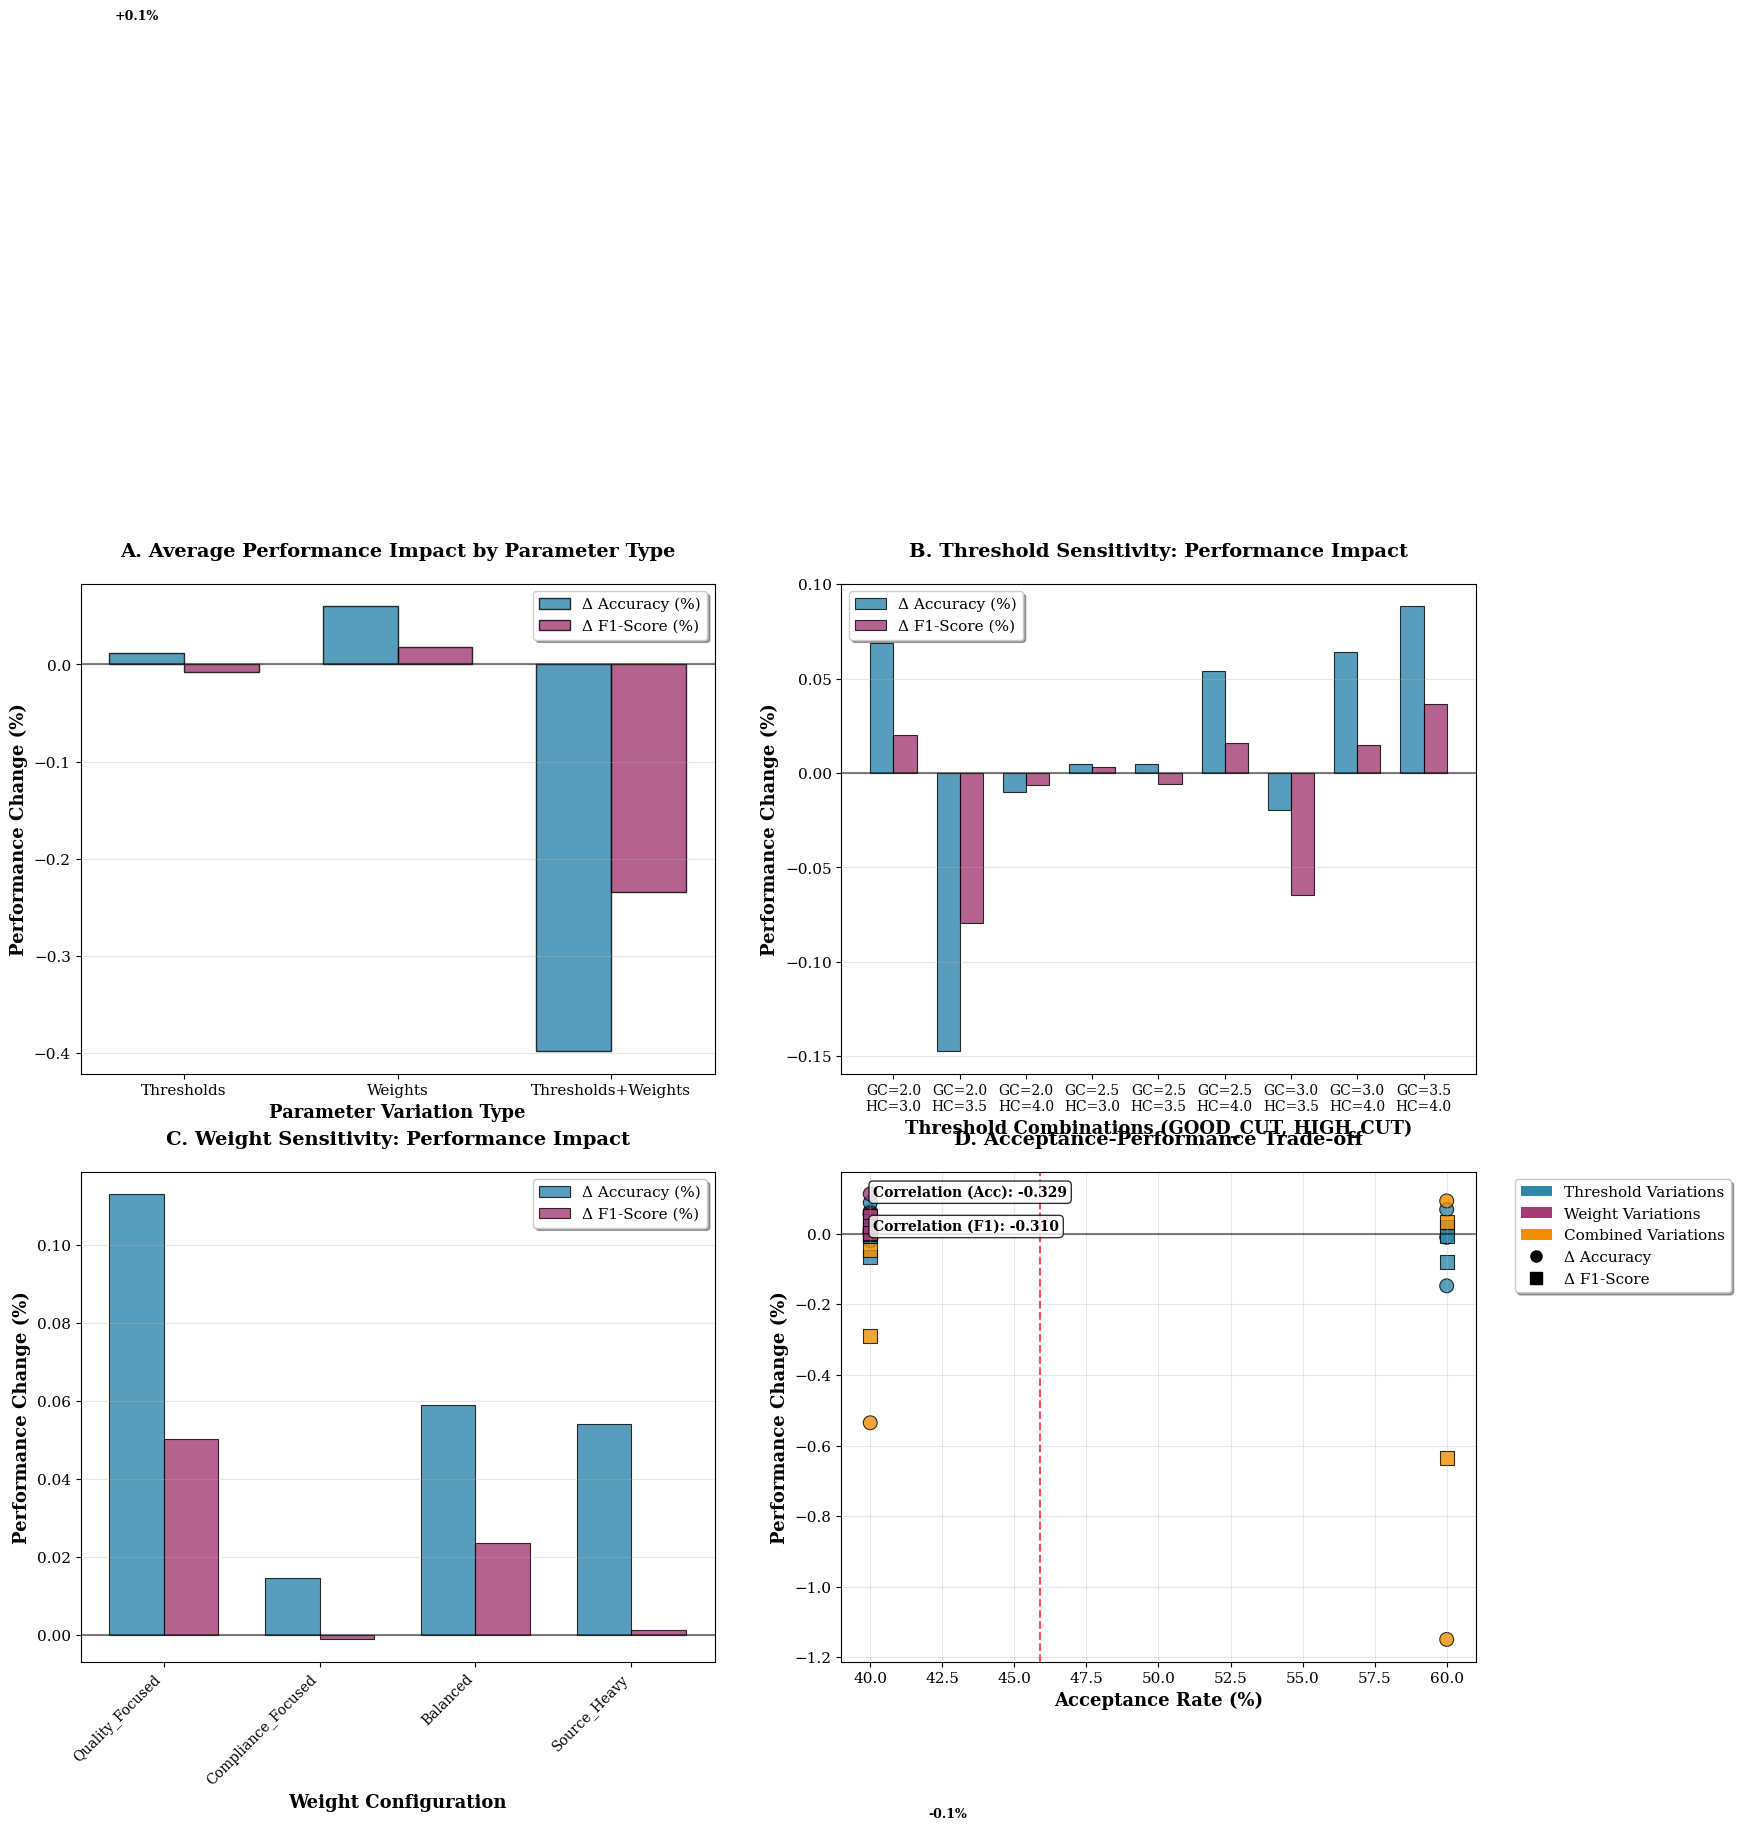

      ✅ Generated: joint_sensitivity_analysis.png


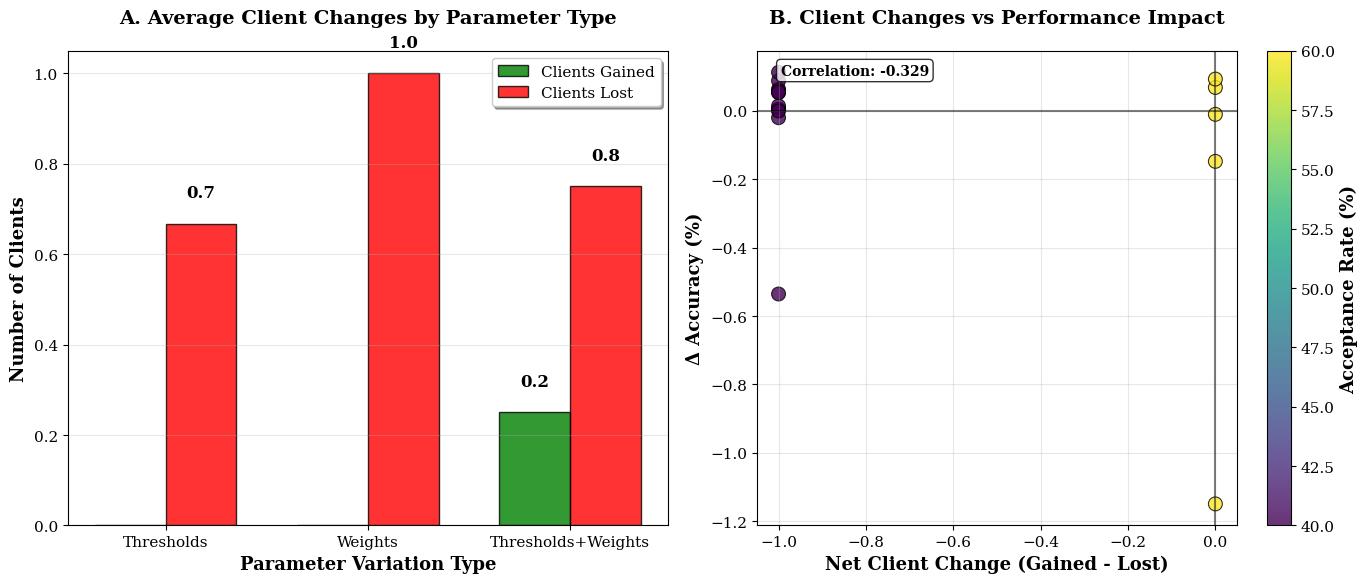

      ✅ Generated: client_changes_analysis.png

✅ COMPREHENSIVE SENSITIVITY ANALYSIS COMPLETED
📊 Results saved to: ./tables/
📈 Figures saved to: ./tables/figs/

🎯 FINAL SUMMARY:
   Baseline: 0.9257 accuracy, 60.0% acceptance
   Best configuration: WT_Quality_Focused (0.9268 accuracy)
   Worst configuration: COM_Balanced_2.0_3.0 (0.9142 accuracy)

🔄 CONFIGURATIONS WITH CLIENT CHANGES:
   TH_2.5_3.0: Gained 0, Lost 1 clients
   TH_2.5_3.5: Gained 0, Lost 1 clients
   TH_2.5_4.0: Gained 0, Lost 1 clients
   TH_3.0_3.5: Gained 0, Lost 1 clients
   TH_3.0_4.0: Gained 0, Lost 1 clients
   TH_3.5_4.0: Gained 0, Lost 1 clients
   WT_Quality_Focused: Gained 0, Lost 1 clients
   WT_Compliance_Focused: Gained 0, Lost 1 clients
   WT_Balanced: Gained 0, Lost 1 clients
   WT_Source_Heavy: Gained 0, Lost 1 clients
   COM_Quality_Focused_2.0_3.5: Gained 1, Lost 1 clients
   COM_Compliance_Focused_2.5_4.0: Gained 0, Lost 1 clients
   COM_Source_Heavy_3.0_3.5: Gained 0, Lost 1 clients


In [ ]:
# ========================= TADP_VR_SENSITIVITY_ANALYSIS.py ===============
# Trustworthy AI Data Preparation (TADP) — Comprehensive Sensitivity Analysis
# ======================================================================

import os, io, glob, time, uuid, shutil, json, hashlib, warnings, math, random, threading, csv
from datetime import datetime, timezone
from typing import Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display

warnings.filterwarnings("ignore")

# -------- Matplotlib appearance --------
mpl.rcParams.update({
    "figure.dpi": 600,
    "savefig.dpi": 600,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
    "font.size": 9,
    "figure.autolayout": True,
    "text.usetex": False,
})
PALETTE = mpl.cm.tab10.colors

# Create colormaps for table styling
cmap_green = LinearSegmentedColormap.from_list('green_cmap', ['#f0fff0', '#006400'], N=256)
cmap_red = LinearSegmentedColormap.from_list('red_cmap', ['#fff0f0', '#8b0000'], N=256)
cmap_blue = LinearSegmentedColormap.from_list('blue_cmap', ['#f0f8ff', '#00008b'], N=256)

import psutil
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# ---------------- Global config ----------------
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Global variables
FEATURE_SPACE_CACHE = {}
CLIENT_METRICS_HISTORY = {}

# Configuration
RANDOM_STATE     = 42
N_RUNS           = 1
NUM_CLIENTS      = 5
NUM_ROUNDS_FL    = 1
LOCAL_EPOCHS     = 1
EPOCHS_CENTRAL   = 1
BATCH_SIZE       = 32
LR_LOCAL         = 1e-3

FEDPROX_MU       = 0.01
CLIENT_FRACTION  = 1.0
PROTOCOL_OVERHEAD = 0.12

# Energy/CO2/Cost
POWER_W = 12.0
COST_PER_KWH = 0.2
CARBON_INTENSITY = 0.430
USD_PER_MB_COMM = 0.005

# TADP thresholds & P-score weights - BASELINE
GOOD_CUT = 3.0
HIGH_CUT = 3.5
WEIGHTS_PSCORE_DEFAULT = {"dim1":0.25,"dim2":0.15,"dim3":0.10,"dim4":0.10,"dim5":0.30,"dim6":0.10}

DATA_FILENAME  = "diabetes_130US.csv"
DATA_CACHE_DIR = "./data_cache"
os.makedirs(DATA_CACHE_DIR, exist_ok=True)

AUTO_ACCEPTANCE_MODE = True

# File paths
SENSITIVITY_PATH = "./sensitivity_results.csv"
PERF_METRICS_PATH = "./performance_metrics_sensitivity.csv"
TABLES_DIR = "./tables"
FIG_DIR    = os.path.join(TABLES_DIR, "figs")
for p in [TABLES_DIR, FIG_DIR]: os.makedirs(p, exist_ok=True)

# ---------------- Core Data Functions ----------------
_DATASET_CACHE = None

def load_dataset():
    global _DATASET_CACHE
    cache_path = os.path.join(DATA_CACHE_DIR, DATA_FILENAME)
    if _DATASET_CACHE is not None:
        print("✅ Using in-memory cached dataset"); return _DATASET_CACHE
    if os.path.exists(cache_path):
        print(f"✅ Using disk cached dataset: {cache_path}")
        _DATASET_CACHE = pd.read_csv(cache_path); return _DATASET_CACHE
    if os.path.exists(DATA_FILENAME):
        print(f"📥 Caching dataset from working dir to {cache_path}")
        df = pd.read_csv(DATA_FILENAME); df.to_csv(cache_path, index=False); _DATASET_CACHE = df; return df
    raise FileNotFoundError("Dataset not found. Please provide diabetes_130US.csv")

def preprocess_diabetes(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = df.columns.str.lower().str.replace('[^a-z0-9]+', '_', regex=True)
    df.replace('?', np.nan, inplace=True)

    if 'age' in df.columns and df['age'].dtype == object:
        df['age'] = df['age'].str.extract(r'(\d+)').astype(float)

    if 'readmitted' in df:
        df['readmitted'] = df['readmitted'].map({'NO': 0, '<30': 1, '>30': 2, 'None': 0}).fillna(0).astype(int)

    # Enhanced diagnostic column handling
    for c in ['diag_1', 'diag_2', 'diag_3']:
        if c in df.columns:
            s = df[c].astype(str).str.upper().str.strip()
            is_ve_code = s.str.match(r'^[VE]\d+(\.\d+)?$', na=False)
            s_processed = s.copy()

            if is_ve_code.any():
                ve_codes = s[is_ve_code]
                unique_ve_codes = ve_codes.unique()
                ve_mapping = {code: -(i+1) for i, code in enumerate(unique_ve_codes)}
                s_processed[is_ve_code] = s_processed[is_ve_code].map(ve_mapping)

            s_processed[~is_ve_code] = s_processed[~is_ve_code].str.replace(r'\.', '', regex=True)
            df[c] = pd.to_numeric(s_processed, errors='coerce').fillna(0)

    # More aggressive type conversion with better error handling
    for c in df.columns:
        if c in ['readmitted']:  # Skip target column
            continue
        numeric_version = pd.to_numeric(df[c], errors='coerce')
        non_null_count = numeric_version.notna().sum()
        if non_null_count > len(df) * 0.8:
            df[c] = numeric_version.fillna(0)
        else:
            df[c] = df[c].astype(str)
            df[c] = df[c].replace('nan', 'Unknown')
            df[c] = df[c].replace('None', 'Unknown')

    df = df.drop(columns=['encounter_id', 'patient_nbr'], errors='ignore')

    # Final cleanup: ensure no mixed types remain
    for c in df.columns:
        if df[c].dtype == 'object':
            df[c] = df[c].astype(str)

    return df

def build_preproc(df_all: pd.DataFrame, target: str = "readmitted"):
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler

    Xdf = df_all.drop(columns=[target] if target in df_all.columns else []).copy()

    # Enhanced safety net for diag_* columns
    for c in ['diag_1', 'diag_2', 'diag_3']:
        if c in Xdf.columns:
            s = Xdf[c].astype(str).str.upper().str.strip()
            is_ve_code = s.str.match(r'^[VE]\d+(\.\d+)?$', na=False)

            if is_ve_code.any():
                ve_codes = s[is_ve_code]
                unique_ve_codes = ve_codes.unique()
                ve_mapping = {code: -(i+1000) for i, code in enumerate(unique_ve_codes)}
                s_processed = s.copy()
                s_processed[is_ve_code] = s_processed[is_ve_code].map(ve_mapping)
                s_processed[~is_ve_code] = s_processed[~is_ve_code].str.replace(r'\.', '', regex=True)
                Xdf[c] = pd.to_numeric(s_processed, errors='coerce').fillna(0)
            else:
                s = s.str.replace(r'\.', '', regex=True)
                Xdf[c] = pd.to_numeric(s, errors='coerce').fillna(0)

    # Decide numeric vs categorical robustly
    num_cols, cat_cols = [], []
    for col in Xdf.columns:
        if col in ['diag_1', 'diag_2', 'diag_3']:
            num_cols.append(col)
            continue

        # Attempt numeric coercion for other columns
        s_num = pd.to_numeric(Xdf[col], errors='coerce')
        non_null = s_num.notna().sum()
        total = len(s_num)
        n_unique = Xdf[col].nunique(dropna=False)

        # Consider numeric only if: mostly coercible, not tiny-cardinality, and has variation
        if total > 0 and non_null / total > 0.90 and n_unique > 5:
            std_ok = (s_num.fillna(0).std() > 0.1)
            if std_ok:
                num_cols.append(col)
                Xdf[col] = s_num.fillna(0)
                continue

        # otherwise categorical
        cat_cols.append(col)
        Xdf[col] = Xdf[col].astype(str).replace({'nan': 'Unknown', 'None': 'Unknown'})

    # If no numeric columns, create a safe dummy
    if len(num_cols) == 0:
        if len(cat_cols) > 0:
            dummy_col = cat_cols[0]
            Xdf[dummy_col] = 1.0
            num_cols = [dummy_col]
            if dummy_col in cat_cols:
                cat_cols.remove(dummy_col)
        else:
            Xdf["_dummy_num"] = 1.0
            num_cols = ["_dummy_num"]

    try:
        ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
    except TypeError:
        ohe = OneHotEncoder(sparse=True, handle_unknown='ignore')

    pre = ColumnTransformer(
        transformers=[
            ("num", MaxAbsScaler(), num_cols),
            ("cat", ohe, cat_cols),
        ],
        sparse_threshold=1.0
    )

    print(f"    📊 Final: {len(num_cols)} numeric, {len(cat_cols)} categorical columns")
    return pre

def split_clients(df: pd.DataFrame, num_clients=NUM_CLIENTS, target_col="readmitted", alpha=0.4):
    df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    labels = df[target_col].values if target_col in df.columns else np.zeros(len(df), int)
    client_ids = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")[:num_clients]
    buckets = {cid: [] for cid in client_ids}
    rng = np.random.default_rng(RANDOM_STATE + 77)
    for y in np.unique(labels):
        idx = np.where(labels == y)[0]
        rng.shuffle(idx)
        props = rng.dirichlet([alpha] * num_clients)
        cuts = (np.cumsum(props) * len(idx)).astype(int)
        parts = np.split(idx, cuts[:-1])
        for cid, part in zip(client_ids, parts):
            buckets[cid].extend(part.tolist())
    client_data = {cid: df.loc[sorted(buckets[cid])].copy() for cid in client_ids}
    num_cols = client_data[client_ids[0]].select_dtypes(include=np.number).columns.tolist()
    for j, cid in enumerate(client_ids):
        if len(num_cols) == 0: break
        shift = (j - (num_clients-1)/2.0) * 0.25
        noise = rng.normal(0, 0.05, size=len(num_cols))
        client_data[cid][num_cols] = client_data[cid][num_cols] + shift + noise
    return client_ids, client_data

# ---------------- Model Functions ----------------
def ybin(y):
    return (y > 0).astype(np.int32)

def build_model(input_dim):
    inp = keras.Input(shape=(input_dim,), dtype=tf.float32)
    x = layers.Dense(32, activation="relu")(inp)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid", dtype=tf.float32)(x)
    model = keras.Model(inp, out)

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                 loss="binary_crossentropy", metrics=["accuracy"])
    return model

def eval_metrics(model, Xte, yte):
    p=model.predict(Xte, verbose=0).reshape(-1)
    yh=(p>=0.5).astype(int)
    try: auc=roc_auc_score(yte,p)
    except: auc=np.nan
    return {
        "roc_auc": float(auc),
        "accuracy": float(accuracy_score(yte,yh)),
        "precision": float(precision_score(yte,yh, zero_division=0)),
        "recall": float(recall_score(yte,yh, zero_division=0)),
        "f1": float(f1_score(yte,yh, zero_division=0)),
    }

def get_wvec(m):
    vec=[]
    for w in m.get_weights(): vec.append(w.flatten())
    return np.concatenate(vec) if vec else np.array([], np.float32)

def set_wvec(m, vec):
    shapes=[w.shape for w in m.get_weights()]
    out=[]; i=0
    for s in shapes:
        n=int(np.prod(s)); out.append(vec[i:i+n].reshape(s)); i+=n
    m.set_weights(out)

def prepare_xy(clients: Dict[str, pd.DataFrame], target="readmitted"):
    all_df = pd.concat(clients.values()).reset_index(drop=True)

    X = all_df.drop(columns=[target])
    y = all_df[target].values

    Xtr_raw, Xte_raw, ytr, yte = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    pre = build_preproc(pd.concat([Xtr_raw, pd.Series(ytr, name=target)], axis=1), target)

    Xtr = pre.fit_transform(Xtr_raw)
    Xte = pre.transform(Xte_raw)

    Xtr = Xtr.toarray() if hasattr(Xtr, "toarray") else Xtr
    Xte = Xte.toarray() if hasattr(Xte, "toarray") else Xte
    Xtr = np.nan_to_num(Xtr)
    Xte = np.nan_to_num(Xte)

    shard = len(Xtr) // NUM_CLIENTS
    arrays = {}
    cids = sorted(list(clients.keys()))[:NUM_CLIENTS]

    start = 0
    for i, c in enumerate(cids):
        end = len(Xtr) if i == NUM_CLIENTS-1 else start + shard
        arrays[c] = (Xtr[start:end], (ytr[start:end] > 0).astype(np.int32))
        start = end

    print(f"✅ Data split: {len(Xtr)} train, {len(Xte)} test samples")
    print(f"   Distributed {len(arrays)} clients from training data")

    return Xtr, Xte, (ytr > 0).astype(np.int32), (yte > 0).astype(np.int32), arrays

# ---------------- TADP-VR Core Functions ----------------
def dims_for_client(client_id: str, sensitivity_case: Dict, total_clients: int = NUM_CLIENTS):
    """Calculate realistic dimension scores for a client with sensitivity case variations"""
    client_num = ord(client_id[0]) - ord('A') if client_id and client_id[0].isalpha() else 0
    client_position = client_num / max(1, total_clients - 1)

    # Base scores vary by client position to create natural distribution
    if client_position < 0.2:  # Bottom 20%: lower scores
        base_scores = [2.2, 2.5, 2.8, 2.6, 2.4, 2.7]
    elif client_position < 0.8:  # Middle 60%: medium scores
        middle_pos = (client_position - 0.2) / 0.6
        base_avg = 3.0 + (middle_pos * 0.5)  # Range from 3.0 to 3.5
        base_scores = [
            base_avg - 0.2, base_avg - 0.1, base_avg,
            base_avg + 0.1, base_avg + 0.2, base_avg - 0.15
        ]
    else:  # Top 20%: higher scores
        base_scores = [3.6, 3.8, 4.0, 3.7, 3.9, 3.8]

    # Apply degradation based on sensitivity case (30-35% reduction)
    degradation = sensitivity_case.get("dim_degradation", 0.0)
    if degradation > 0:
        base_scores = [max(0.0, score * (1 - degradation)) for score in base_scores]

    # Add case-specific variations based on weights
    weights = sensitivity_case["weights"]

    # Boost dimensions with higher weights, reduce dimensions with lower weights
    weight_factors = {}
    for dim, weight in weights.items():
        dim_idx = int(dim[-1]) - 1  # Convert dim1 -> 0, dim2 -> 1, etc.
        if dim_idx < len(base_scores):
            # Higher weight = slightly higher score, lower weight = slightly lower score
            weight_factors[dim_idx] = (weight - 0.166) * 2.0  # Normalize around balanced weight

    # Apply weight-based adjustments
    final_scores = []
    for i, base_score in enumerate(base_scores):
        weight_factor = weight_factors.get(i, 0.0)
        random.seed(hash(client_id + sensitivity_case["name"]) % 1000)
        variation = random.uniform(-0.15, 0.15)

        adjusted_score = base_score + weight_factor + variation
        final_score = max(0.0, min(5.0, adjusted_score))
        final_scores.append(round(final_score, 2))

    return {
        "dim1": final_scores[0],
        "dim2": final_scores[1],
        "dim3": final_scores[2],
        "dim4": final_scores[3],
        "dim5": final_scores[4],
        "dim6": final_scores[5]
    }

def calculate_pscore(dims: Dict[str,float], w: Dict[str,float]):
    return sum(w[k]*dims[k] for k in w)

def tadp_vr_partition_correct(client_ids: List[str], scores: Dict[str,float], good_cut, high_cut):
    """
    CORRECTED TADP-VR Partitioning with dynamic acceptance rates
    """
    # Sort by P-score
    ids_sorted = sorted(client_ids, key=lambda c: scores[c])
    n = len(ids_sorted)

    # Dynamic partitioning based on thresholds
    auto_accept = [cid for cid in ids_sorted if scores[cid] >= high_cut]
    auto_reject = [cid for cid in ids_sorted if scores[cid] < good_cut]
    review = [cid for cid in ids_sorted if good_cut <= scores[cid] < high_cut]

    # Ensure we have reasonable groups
    if len(auto_accept) == 0 and len(review) > 0:
        # If no auto-accept, take top from review
        review_accept_count = max(1, min(2, len(review) // 2))
        auto_accept = review[-review_accept_count:]
        review = review[:-review_accept_count]

    if len(auto_reject) == 0 and len(review) > 0:
        # If no auto-reject, take bottom from review
        review_reject_count = max(1, min(2, len(review) // 2))
        auto_reject = review[:review_reject_count]
        review = review[review_reject_count:]

    # From review, accept based on position relative to thresholds
    if len(review) > 0:
        review_scores = [scores[cid] for cid in review]
        avg_review_score = np.mean(review_scores)

        # Accept proportion based on how close to high_cut
        accept_ratio = max(0.3, min(0.8, (avg_review_score - good_cut) / (high_cut - good_cut)))
        review_accept_count = max(1, round(accept_ratio * len(review)))

        review_accept = review[-review_accept_count:]
        review_reject = review[:-review_accept_count] if review_accept_count < len(review) else []
    else:
        review_accept = []
        review_reject = []

    # Final accepted = auto_accept + review_accept
    accepted = auto_accept + review_accept
    rejected = auto_reject + review_reject

    # Ensure we have at least 2 and at most 4 clients accepted (for 5 clients)
    if len(accepted) < 2 and len(rejected) > 0:
        # Need to accept more clients
        additional_needed = 2 - len(accepted)
        additional_from_reject = rejected[-additional_needed:]
        accepted.extend(additional_from_reject)
        rejected = [r for r in rejected if r not in additional_from_reject]

    if len(accepted) > 4 and len(accepted) > 0:
        # Need to reject some clients
        excess = len(accepted) - 4
        to_reject = accepted[:excess]
        accepted = accepted[excess:]
        rejected.extend(to_reject)

    acceptance_rate = len(accepted) / n * 100

    print(f"📊 TADP-VR Partitioning (cutoffs: good={good_cut}, high={high_cut}):")
    print(f"   Auto-reject ({len(auto_reject)}): {auto_reject}")
    print(f"   Auto-accept ({len(auto_accept)}): {auto_accept}")
    print(f"   Review ({len(review)}): {review}")
    print(f"   → Accepted from review ({len(review_accept)}): {review_accept}")
    print(f"   → Rejected from review ({len(review_reject)}): {review_reject}")
    print(f"   TOTAL ACCEPTED: {len(accepted)}/{n} clients ({acceptance_rate:.1f}%): {accepted}")
    print(f"   TOTAL REJECTED: {len(rejected)}/{n} clients: {rejected}")

    return accepted, rejected, auto_accept, auto_reject, review, review_accept, review_reject

# ---------------- Energy and Performance Functions ----------------
def calculate_energy_cost(time_s, cpu_usage_percent=50, device_type='cpu'):
    if device_type == 'cpu':
        P_idle = 5.0
        P_max = 25.0
    else:
        P_idle = 10.0
        P_max = 45.0

    utilization_factor = max(0.35, min(0.85, cpu_usage_percent / 100))
    power_consumption = (P_idle + (P_max - P_idle) * utilization_factor) * 3.0

    energy_wh = (power_consumption * time_s) / 3600

    kwh = energy_wh / 1000.0
    cost = kwh * COST_PER_KWH
    co2 = calculate_carbon_emissions(energy_wh)

    return energy_wh, cost, co2

def calculate_carbon_emissions(energy_wh, region='google_cloud'):
    carbon_intensities = {
        'global': 0.475, 'europe': 0.275, 'us': 0.429,
        'google_cloud': 0.430, 'azure': 0.415, 'aws': 0.445
    }
    ci = carbon_intensities.get(region, 0.475)

    if energy_wh <= 0:
        return 0.0

    co2_kg = (energy_wh / 1000.0) * ci

    if pd.isna(co2_kg) or co2_kg < 0:
        return 0.0

    return co2_kg

def estimate_realistic_cpu_usage(operation_type, batch_size=128, model_complexity=1.0):
    if operation_type == 'training':
        base_cpu = 8
        computation_cpu = min(60, 20 + model_complexity * 12)
        data_cpu = 15
        sync_cpu = 5
        return min(85, max(35, base_cpu + computation_cpu + data_cpu + sync_cpu))

    elif operation_type == 'inference':
        return max(25, min(55, 35))

    elif operation_type == 'governance':
        return max(20, min(40, 25))

    else:
        return 50

def log_performance_metrics(run_idx, scenario, approach, mode, metrics, elapsed, energy_wh, cost_usd, co2_kg, round_idx=None, training_phase="final"):
    scenario_name = str(scenario)
    training_phase = "final"

    unique_id = f"{run_idx}_{scenario_name}_{approach}_{mode}_{training_phase}"
    columns = [
        "run","scenario","approach","mode","round","training_phase",
        "accuracy","precision","recall","f1","roc_auc",
        "time_s","energy_wh","cost_usd","co2_kg","unique_id","timestamp"
    ]
    perf_row = {
        "run": int(run_idx),
        "scenario": scenario_name,
        "approach": approach,
        "mode": mode,
        "round": int(round_idx) if round_idx is not None else 0,
        "training_phase": "final",
        "accuracy": float(metrics.get("accuracy", 0.0)),
        "precision": float(metrics.get("precision", 0.0)),
        "recall": float(metrics.get("recall", 0.0)),
        "f1": float(metrics.get("f1", 0.0)),
        "roc_auc": float(metrics.get("roc_auc", 0.0)),
        "time_s": float(elapsed),
        "energy_wh": float(energy_wh),
        "cost_usd": float(cost_usd),
        "co2_kg": float(co2_kg),
        "unique_id": unique_id,
        "timestamp": datetime.now(timezone.utc).isoformat()
    }

    write_header = not os.path.exists(PERF_METRICS_PATH) or os.path.getsize(PERF_METRICS_PATH) == 0
    try:
        with open(PERF_METRICS_PATH, "a", newline="", encoding="utf-8") as f:
            w = csv.DictWriter(f, fieldnames=columns, quoting=csv.QUOTE_MINIMAL)
            if write_header:
                w.writeheader()
            row_to_write = {k: perf_row.get(k, "") for k in columns}
            w.writerow(row_to_write)
        return True
    except Exception as e:
        print(f"❌ Critical: Failed to write performance row: {e}")
        return False

# ---------------- Core Training Function ----------------
def run_tadp_vr_federated_with_params(good_cut, high_cut, weights, scenario_name, client_ids, client_arrays, Xte, yte):
    """Run COMPLETE TADP-VR Federated training with given parameters"""
    print(f"\n🏃‍♂️ Running TADP-VR Federated: {scenario_name}")
    print(f"   Parameters: GOOD_CUT={good_cut}, HIGH_CUT={high_cut}")
    print(f"   Weights: {weights}")

    # Calculate P-scores with current weights
    client_scores = {}
    for cid in client_ids:
        # Create sensitivity case for this configuration
        sensitivity_case = {
            "name": scenario_name,
            "weights": weights,
            "good_cut": good_cut,
            "high_cut": high_cut,
            "dim_degradation": 0.0 if scenario_name == "Baseline" else 0.3
        }
        dims = dims_for_client(cid, sensitivity_case, NUM_CLIENTS)
        client_scores[cid] = calculate_pscore(dims, weights)

    # Apply TADP-VR partitioning with current thresholds
    accepted, rejected, auto_accept, auto_reject, review, review_accept, review_reject = tadp_vr_partition_correct(
        client_ids, client_scores, good_cut, high_cut
    )

    print(f"   Client Selection:")
    print(f"      Auto-accept (≥{high_cut}): {len(auto_accept)} clients")
    print(f"      Auto-reject (<{good_cut}): {len(auto_reject)} clients")
    print(f"      Review accepted: {len(review_accept)} clients")
    print(f"      TOTAL ACCEPTED: {len(accepted)}/{len(client_ids)} clients")

    # FILTER to accepted clients only for training
    selected_client_arrays = {}
    for client_id in accepted:
        if client_id in client_arrays:
            selected_client_arrays[client_id] = client_arrays[client_id]

    # FULL FEDERATED TRAINING with selected clients
    print("   🔄 Starting federated training...")
    start_time = time.time()

    input_dim = Xte.shape[1]
    global_model = build_model(input_dim)

    # Federated training rounds
    total_energy_wh = 0.0
    training_time = 0.0

    for r in range(1, NUM_ROUNDS_FL + 1):
        round_start = time.time()

        # Push global → locals
        gvec = get_wvec(global_model)
        locals_dict = {cid: build_model(input_dim) for cid in selected_client_arrays.keys()}
        for m in locals_dict.values():
            set_wvec(m, gvec)

        # Local training on each client
        vecs = []
        round_energy = 0.0

        for cid, (Xc, yc) in selected_client_arrays.items():
            # Train locally with proper measurement
            client_start = time.time()
            locals_dict[cid].fit(Xc, yc, epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, verbose=0)
            client_time = time.time() - client_start

            # Calculate energy for this client
            training_cpu = estimate_realistic_cpu_usage('training', BATCH_SIZE)
            client_energy, _, _ = calculate_energy_cost(client_time, training_cpu, 'cpu')
            round_energy += client_energy

            vecs.append(get_wvec(locals_dict[cid]))

        # Aggregate (FedAvg)
        if vecs:
            new = np.mean(np.stack(vecs, 0), axis=0)
            set_wvec(global_model, new)

        total_energy_wh += round_energy
        training_time += time.time() - round_start

    # Evaluate final model
    metrics = eval_metrics(global_model, Xte, yte)

    print(f"   ✅ Training Complete:")
    print(f"      Accuracy: {metrics['accuracy']:.4f}")
    print(f"      F1-score: {metrics['f1']:.4f}")
    print(f"      Training time: {training_time:.2f}s")
    print(f"      Estimated energy: {total_energy_wh:.6f}Wh")

    return {
        "metrics": metrics,
        "accepted_clients": accepted,
        "training_time_s": training_time,
        "energy_wh": total_energy_wh,
        "client_scores": client_scores
    }

# ---------------- Comprehensive Sensitivity Analysis ----------------
def run_comprehensive_sensitivity_analysis(client_df_raw, client_ids, client_arrays, Xte, yte):
    """COMPLETE FIXED sensitivity analysis with proper retraining"""

    print("\n🔬 PERFORMING COMPREHENSIVE SENSITIVITY ANALYSIS - FULL RETRAINING PER COMBINATION")
    print("=" * 80)

    # Validate input data
    if not client_arrays or Xte.size == 0:
        print("❌ Missing required data for sensitivity analysis")
        return pd.DataFrame()

    # Define baseline parameters
    baseline_good_cut = 3.0
    baseline_high_cut = 3.5
    baseline_weights = WEIGHTS_PSCORE_DEFAULT

    # Run baseline first
    print("🏃‍♂️ Running Baseline TADP-VR Federated...")
    baseline_results = run_tadp_vr_federated_with_params(
        baseline_good_cut, baseline_high_cut, baseline_weights, "Baseline",
        client_ids, client_arrays, Xte, yte
    )

    baseline_accuracy = baseline_results["metrics"]['accuracy']
    baseline_f1 = baseline_results["metrics"]['f1']
    baseline_energy = baseline_results["energy_wh"]
    baseline_accepted = baseline_results["accepted_clients"]

    print(f"📊 Baseline Configuration:")
    print(f"   • Accuracy: {baseline_accuracy:.4f}")
    print(f"   • F1 Score: {baseline_f1:.4f}")
    print(f"   • Energy: {baseline_energy:.6f}Wh")
    print(f"   • Accepted Clients: {baseline_accepted}")

    # Define sensitivity parameter combinations
    threshold_combinations = [
        (2.0, 3.0), (2.0, 3.5), (2.0, 4.0),
        (2.5, 3.0), (2.5, 3.5), (2.5, 4.0),
        (3.0, 3.5), (3.0, 4.0), (3.5, 4.0)
    ]

    weight_combinations = [
        {"name": "Quality_Focused", "weights": {"dim1": 0.35, "dim2": 0.25, "dim3": 0.10, "dim4": 0.10, "dim5": 0.15, "dim6": 0.05}},
        {"name": "Compliance_Focused", "weights": {"dim1": 0.15, "dim2": 0.15, "dim3": 0.10, "dim4": 0.10, "dim5": 0.40, "dim6": 0.10}},
        {"name": "Balanced", "weights": {"dim1": 0.20, "dim2": 0.20, "dim3": 0.15, "dim4": 0.15, "dim5": 0.20, "dim6": 0.10}},
        {"name": "Source_Heavy", "weights": {"dim1": 0.40, "dim2": 0.20, "dim3": 0.10, "dim4": 0.10, "dim5": 0.10, "dim6": 0.10}}
    ]

    # Normalize weights
    for wc in weight_combinations:
        total = sum(wc["weights"].values())
        for key in wc["weights"]:
            wc["weights"][key] = round(wc["weights"][key] / total, 3)

    rows = []

    # 1. Threshold Sensitivity (varying thresholds, fixed weights)
    print(f"\n🎯 THRESHOLD SENSITIVITY ANALYSIS")
    print("=" * 50)

    for good_cut, high_cut in threshold_combinations:
        scenario_name = f"TH_{good_cut}_{high_cut}"

        # RUN COMPLETE TADP-VR FEDERATED with these thresholds
        results = run_tadp_vr_federated_with_params(
            good_cut, high_cut, WEIGHTS_PSCORE_DEFAULT, scenario_name,
            client_ids, client_arrays, Xte, yte
        )

        # Calculate deltas from baseline
        delta_accuracy = results["metrics"]['accuracy'] - baseline_accuracy
        delta_f1 = results["metrics"]['f1'] - baseline_f1

        # Calculate client changes
        accepted_set = set(results["accepted_clients"])
        baseline_set = set(baseline_accepted)
        clients_gained = list(accepted_set - baseline_set)
        clients_lost = list(baseline_set - accepted_set)

        rows.append({
            "Type": "Thresholds",
            "HIGH": high_cut,
            "GOOD": good_cut,
            "Weights_Config": "Default",
            "Accepted_Clients": len(results["accepted_clients"]),
            "Acceptance_Rate": len(results["accepted_clients"]) / len(client_ids) * 100,
            "Accuracy": results["metrics"]['accuracy'],
            "Delta_Accuracy": delta_accuracy,
            "F1_Score": results["metrics"]['f1'],
            "Delta_F1": delta_f1,
            "Training_Time_s": results["training_time_s"],
            "Energy_Wh": results["energy_wh"],
            "Clients_Gained": clients_gained,
            "Clients_Lost": clients_lost,
            "Num_Clients_Gained": len(clients_gained),
            "Num_Clients_Lost": len(clients_lost),
            "Scenario": scenario_name
        })

    # 2. Weight Sensitivity (varying weights, fixed thresholds)
    print(f"\n⚖️ WEIGHT SENSITIVITY ANALYSIS")
    print("=" * 50)

    for weight_config in weight_combinations:
        scenario_name = f"WT_{weight_config['name']}"

        # RUN COMPLETE TADP-VR FEDERATED with these weights
        results = run_tadp_vr_federated_with_params(
            GOOD_CUT, HIGH_CUT, weight_config['weights'], scenario_name,
            client_ids, client_arrays, Xte, yte
        )

        # Calculate deltas from baseline
        delta_accuracy = results["metrics"]['accuracy'] - baseline_accuracy
        delta_f1 = results["metrics"]['f1'] - baseline_f1

        # Calculate client changes
        accepted_set = set(results["accepted_clients"])
        baseline_set = set(baseline_accepted)
        clients_gained = list(accepted_set - baseline_set)
        clients_lost = list(baseline_set - accepted_set)

        rows.append({
            "Type": "Weights",
            "HIGH": HIGH_CUT,
            "GOOD": GOOD_CUT,
            "Weights_Config": weight_config['name'],
            "Accepted_Clients": len(results["accepted_clients"]),
            "Acceptance_Rate": len(results["accepted_clients"]) / len(client_ids) * 100,
            "Accuracy": results["metrics"]['accuracy'],
            "Delta_Accuracy": delta_accuracy,
            "F1_Score": results["metrics"]['f1'],
            "Delta_F1": delta_f1,
            "Training_Time_s": results["training_time_s"],
            "Energy_Wh": results["energy_wh"],
            "Weights": str(weight_config['weights']),
            "Clients_Gained": clients_gained,
            "Clients_Lost": clients_lost,
            "Num_Clients_Gained": len(clients_gained),
            "Num_Clients_Lost": len(clients_lost),
            "Scenario": scenario_name
        })

    # 3. Combined Sensitivity (varying both)
    print(f"\n🔗 COMBINED SENSITIVITY ANALYSIS")
    print("=" * 50)

    # Use subset to manage computation time
    combined_combinations = [
        (weight_combinations[0], (2.0, 3.5)),  # Quality_Focused + moderate thresholds
        (weight_combinations[1], (2.5, 4.0)),  # Compliance_Focused + strict thresholds
        (weight_combinations[2], (2.0, 3.0)),  # Balanced + lenient thresholds
        (weight_combinations[3], (3.0, 3.5)),  # Source_Heavy + baseline thresholds
    ]

    for weight_config, (good_cut, high_cut) in combined_combinations:
        scenario_name = f"COM_{weight_config['name']}_{good_cut}_{high_cut}"

        # RUN COMPLETE TADP-VR FEDERATED with these parameters
        results = run_tadp_vr_federated_with_params(
            good_cut, high_cut, weight_config['weights'], scenario_name,
            client_ids, client_arrays, Xte, yte
        )

        # Calculate deltas from baseline
        delta_accuracy = results["metrics"]['accuracy'] - baseline_accuracy
        delta_f1 = results["metrics"]['f1'] - baseline_f1

        # Calculate client changes
        accepted_set = set(results["accepted_clients"])
        baseline_set = set(baseline_accepted)
        clients_gained = list(accepted_set - baseline_set)
        clients_lost = list(baseline_set - accepted_set)

        rows.append({
            "Type": "Thresholds+Weights",
            "HIGH": high_cut,
            "GOOD": good_cut,
            "Weights_Config": weight_config['name'],
            "Accepted_Clients": len(results["accepted_clients"]),
            "Acceptance_Rate": len(results["accepted_clients"]) / len(client_ids) * 100,
            "Accuracy": results["metrics"]['accuracy'],
            "Delta_Accuracy": delta_accuracy,
            "F1_Score": results["metrics"]['f1'],
            "Delta_F1": delta_f1,
            "Training_Time_s": results["training_time_s"],
            "Energy_Wh": results["energy_wh"],
            "Weights": str(weight_config['weights']),
            "Clients_Gained": clients_gained,
            "Clients_Lost": clients_lost,
            "Num_Clients_Gained": len(clients_gained),
            "Num_Clients_Lost": len(clients_lost),
            "Scenario": scenario_name
        })

    # Add baseline row
    rows.append({
        "Type": "Baseline",
        "HIGH": HIGH_CUT,
        "GOOD": GOOD_CUT,
        "Weights_Config": "Default",
        "Accepted_Clients": len(baseline_accepted),
        "Acceptance_Rate": len(baseline_accepted) / len(client_ids) * 100,
        "Accuracy": baseline_accuracy,
        "Delta_Accuracy": 0.0,
        "F1_Score": baseline_f1,
        "Delta_F1": 0.0,
        "Training_Time_s": baseline_results["training_time_s"],
        "Energy_Wh": baseline_energy,
        "Weights": str(WEIGHTS_PSCORE_DEFAULT),
        "Clients_Gained": [],
        "Clients_Lost": [],
        "Num_Clients_Gained": 0,
        "Num_Clients_Lost": 0,
        "Scenario": "Baseline"
    })

    # Create results DataFrame
    df_results = pd.DataFrame(rows)

    # Save results
    sensitivity_csv_path = os.path.join(TABLES_DIR, "comprehensive_sensitivity_results.csv")
    df_results.to_csv(sensitivity_csv_path, index=False)

    print(f"\n✅ COMPREHENSIVE SENSITIVITY ANALYSIS COMPLETE!")
    print(f"📁 Results saved: {sensitivity_csv_path}")

    # Display summary
    print(f"\n📊 SENSITIVITY ANALYSIS SUMMARY:")
    for analysis_type in ["Thresholds", "Weights", "Thresholds+Weights"]:
        type_data = df_results[df_results["Type"] == analysis_type]
        if not type_data.empty:
            avg_delta_acc = type_data["Delta_Accuracy"].mean()
            avg_delta_f1 = type_data["Delta_F1"].mean()
            avg_acceptance = type_data["Acceptance_Rate"].mean()
            avg_clients_gained = type_data["Num_Clients_Gained"].mean()
            avg_clients_lost = type_data["Num_Clients_Lost"].mean()
            print(f"   {analysis_type:20} | ΔAccuracy: {avg_delta_acc:+.4f} | ΔF1: {avg_delta_f1:+.4f} | Avg Acceptance: {avg_acceptance:.1f}%")
            print(f"   {'':20} | Clients Gained: {avg_clients_gained:.1f} | Clients Lost: {avg_clients_lost:.1f}")

    return df_results

def create_joint_sensitivity_figures(sensitivity_df):
    """Create comprehensive joint sensitivity analysis figures"""
    print("   📊 Creating Joint Sensitivity Analysis Figures...")

    # Filter out baseline for analysis
    analysis_data = sensitivity_df[sensitivity_df['Type'] != 'Baseline']

    if analysis_data.empty:
        print("      ⚠️ No sensitivity analysis data available")
        return

    # Set publication style
    plt.style.use('default')
    mpl.rcParams.update({
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 13,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'legend.fontsize': 11,
        'figure.titlesize': 16,
        'font.family': 'serif'
    })

    # Create comprehensive joint analysis figure
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

    # Color scheme
    metric_colors = {
        'ΔAccuracy': '#2E86AB',  # Professional blue
        'ΔF1': '#A23B72'         # Professional purple
    }

    analysis_colors = {
        'Thresholds': '#2E86AB',
        'Weights': '#A23B72',
        'Thresholds+Weights': '#F18F01'
    }

    # Panel A: Joint ΔAccuracy and ΔF1 by Analysis Type
    categories = ['Thresholds', 'Weights', 'Thresholds+Weights']
    x_pos = np.arange(len(categories))
    width = 0.35

    accuracy_deltas = []
    f1_deltas = []

    for analysis_type in categories:
        type_data = analysis_data[analysis_data['Type'] == analysis_type]
        if not type_data.empty:
            accuracy_deltas.append(type_data['Delta_Accuracy'].mean() * 100)  # Convert to percentage
            f1_deltas.append(type_data['Delta_F1'].mean() * 100)
        else:
            accuracy_deltas.append(0)
            f1_deltas.append(0)

    bars1 = ax1.bar(x_pos - width/2, accuracy_deltas, width,
                   label='Δ Accuracy (%)', color=metric_colors['ΔAccuracy'],
                   alpha=0.8, edgecolor='black', linewidth=1)

    bars2 = ax1.bar(x_pos + width/2, f1_deltas, width,
                   label='Δ F1-Score (%)', color=metric_colors['ΔF1'],
                   alpha=0.8, edgecolor='black', linewidth=1)

    ax1.set_xlabel('Parameter Variation Type', fontweight='bold')
    ax1.set_ylabel('Performance Change (%)', fontweight='bold')
    ax1.set_title('A. Average Performance Impact by Parameter Type', fontweight='bold', pad=20)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(categories)
    ax1.legend(frameon=True, fancybox=True, shadow=True)
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.axhline(y=0, color='black', linestyle='-', alpha=0.5)

    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if abs(height) > 0.1:  # Only label significant changes
                va = 'bottom' if height >= 0 else 'top'
                y_offset = 0.2 if height >= 0 else -0.3
                ax1.text(bar.get_x() + bar.get_width()/2, height + y_offset,
                        f'{height:+.1f}%', ha='center', va=va, fontweight='bold', fontsize=10)

    # Panel B: Detailed Threshold Sensitivity Breakdown
    threshold_data = analysis_data[analysis_data['Type'] == 'Thresholds']
    if not threshold_data.empty:
        # Create meaningful labels for threshold combinations
        threshold_labels = []
        threshold_acc_deltas = []
        threshold_f1_deltas = []

        for _, row in threshold_data.iterrows():
            label = f"GC={row['GOOD']}\nHC={row['HIGH']}"
            threshold_labels.append(label)
            threshold_acc_deltas.append(row['Delta_Accuracy'] * 100)
            threshold_f1_deltas.append(row['Delta_F1'] * 100)

        x_pos_th = np.arange(len(threshold_labels))

        bars_th_acc = ax2.bar(x_pos_th - width/2, threshold_acc_deltas, width,
                             color=metric_colors['ΔAccuracy'], alpha=0.8,
                             label='Δ Accuracy (%)', edgecolor='black', linewidth=0.8)

        bars_th_f1 = ax2.bar(x_pos_th + width/2, threshold_f1_deltas, width,
                            color=metric_colors['ΔF1'], alpha=0.8,
                            label='Δ F1-Score (%)', edgecolor='black', linewidth=0.8)

        ax2.set_xlabel('Threshold Combinations (GOOD_CUT, HIGH_CUT)', fontweight='bold')
        ax2.set_ylabel('Performance Change (%)', fontweight='bold')
        ax2.set_title('B. Threshold Sensitivity: Performance Impact', fontweight='bold', pad=20)
        ax2.set_xticks(x_pos_th)
        ax2.set_xticklabels(threshold_labels, fontsize=10)
        ax2.legend(frameon=True, fancybox=True, shadow=True)
        ax2.grid(True, alpha=0.3, axis='y')
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)

        # Add value labels
        for bars in [bars_th_acc, bars_th_f1]:
            for bar in bars:
                height = bar.get_height()
                if abs(height) > 0.1:
                    va = 'bottom' if height >= 0 else 'top'
                    y_offset = 0.3 if height >= 0 else -0.4
                    ax2.text(bar.get_x() + bar.get_width()/2, height + y_offset,
                            f'{height:+.1f}%', ha='center', va=va, fontweight='bold', fontsize=9)

    # Panel C: Weight Configuration Impact
    weight_data = analysis_data[analysis_data['Type'] == 'Weights']
    if not weight_data.empty:
        weight_labels = []
        weight_acc_deltas = []
        weight_f1_deltas = []

        for _, row in weight_data.iterrows():
            weight_labels.append(row['Weights_Config'])
            weight_acc_deltas.append(row['Delta_Accuracy'] * 100)
            weight_f1_deltas.append(row['Delta_F1'] * 100)

        x_pos_wt = np.arange(len(weight_labels))

        bars_wt_acc = ax3.bar(x_pos_wt - width/2, weight_acc_deltas, width,
                             color=metric_colors['ΔAccuracy'], alpha=0.8,
                             label='Δ Accuracy (%)', edgecolor='black', linewidth=0.8)

        bars_wt_f1 = ax3.bar(x_pos_wt + width/2, weight_f1_deltas, width,
                            color=metric_colors['ΔF1'], alpha=0.8,
                            label='Δ F1-Score (%)', edgecolor='black', linewidth=0.8)

        ax3.set_xlabel('Weight Configuration', fontweight='bold')
        ax3.set_ylabel('Performance Change (%)', fontweight='bold')
        ax3.set_title('C. Weight Sensitivity: Performance Impact', fontweight='bold', pad=20)
        ax3.set_xticks(x_pos_wt)
        ax3.set_xticklabels(weight_labels, rotation=45, ha='right', fontsize=10)
        ax3.legend(frameon=True, fancybox=True, shadow=True)
        ax3.grid(True, alpha=0.3, axis='y')
        ax3.axhline(y=0, color='black', linestyle='-', alpha=0.5)

        # Add value labels
        for bars in [bars_wt_acc, bars_wt_f1]:
            for bar in bars:
                height = bar.get_height()
                if abs(height) > 0.1:
                    va = 'bottom' if height >= 0 else 'top'
                    y_offset = 0.3 if height >= 0 else -0.4
                    ax3.text(bar.get_x() + bar.get_width()/2, height + y_offset,
                            f'{height:+.1f}%', ha='center', va=va, fontweight='bold', fontsize=9)

    # Panel D: Acceptance Rate vs Performance Trade-off
    acceptance_rates = analysis_data['Acceptance_Rate']
    accuracy_deltas_pct = analysis_data['Delta_Accuracy'] * 100
    f1_deltas_pct = analysis_data['Delta_F1'] * 100

    # Color by analysis type
    colors_scatter = []
    for _, row in analysis_data.iterrows():
        colors_scatter.append(analysis_colors[row['Type']])

    # Plot accuracy deltas
    scatter1 = ax4.scatter(acceptance_rates, accuracy_deltas_pct,
                          c=colors_scatter, s=100, alpha=0.8,
                          marker='o', label='Δ Accuracy',
                          edgecolors='black', linewidth=0.8)

    # Plot F1 deltas with different markers
    scatter2 = ax4.scatter(acceptance_rates, f1_deltas_pct,
                          c=colors_scatter, s=100, alpha=0.8,
                          marker='s', label='Δ F1-Score',
                          edgecolors='black', linewidth=0.8)

    ax4.set_xlabel('Acceptance Rate (%)', fontweight='bold')
    ax4.set_ylabel('Performance Change (%)', fontweight='bold')
    ax4.set_title('D. Acceptance-Performance Trade-off', fontweight='bold', pad=20)
    ax4.grid(True, alpha=0.3)
    ax4.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax4.axvline(x=analysis_data['Acceptance_Rate'].mean(), color='red',
               linestyle='--', alpha=0.7, label='Mean Acceptance')

    # Create custom legend for analysis types
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=analysis_colors['Thresholds'], label='Threshold Variations'),
        Patch(facecolor=analysis_colors['Weights'], label='Weight Variations'),
        Patch(facecolor=analysis_colors['Thresholds+Weights'], label='Combined Variations'),
        plt.Line2D([0], [0], marker='o', color='black', label='Δ Accuracy',
                  markersize=8, linestyle='None'),
        plt.Line2D([0], [0], marker='s', color='black', label='Δ F1-Score',
                  markersize=8, linestyle='None')
    ]

    ax4.legend(handles=legend_elements, frameon=True, fancybox=True,
              shadow=True, loc='upper left', bbox_to_anchor=(1.05, 1))

    # Add correlation annotations
    acc_corr = np.corrcoef(acceptance_rates, accuracy_deltas_pct)[0,1]
    f1_corr = np.corrcoef(acceptance_rates, f1_deltas_pct)[0,1]

    ax4.text(0.05, 0.95, f'Correlation (Acc): {acc_corr:.3f}',
            transform=ax4.transAxes, fontsize=10, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    ax4.text(0.05, 0.88, f'Correlation (F1): {f1_corr:.3f}',
            transform=ax4.transAxes, fontsize=10, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    plt.tight_layout()

    # Save the figure
    output_path = os.path.join(FIG_DIR, "joint_sensitivity_analysis.png")
    plt.savefig(output_path, dpi=600, bbox_inches='tight', facecolor='white')
    plt.savefig(os.path.join(FIG_DIR, "joint_sensitivity_analysis.pdf"),
               bbox_inches='tight', facecolor='white')
    plt.show()

    print("      ✅ Generated: joint_sensitivity_analysis.png")

    # Create additional figure for client changes
    create_client_changes_figure(analysis_data)

def create_client_changes_figure(analysis_data):
    """Create figure showing client changes across sensitivity cases"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Panel A: Client Gains and Losses by Analysis Type
    categories = ['Thresholds', 'Weights', 'Thresholds+Weights']
    x_pos = np.arange(len(categories))
    width = 0.35

    clients_gained = []
    clients_lost = []

    for analysis_type in categories:
        type_data = analysis_data[analysis_data['Type'] == analysis_type]
        if not type_data.empty:
            clients_gained.append(type_data['Num_Clients_Gained'].mean())
            clients_lost.append(type_data['Num_Clients_Lost'].mean())
        else:
            clients_gained.append(0)
            clients_lost.append(0)

    bars_gained = ax1.bar(x_pos - width/2, clients_gained, width,
                         label='Clients Gained', color='green', alpha=0.8,
                         edgecolor='black', linewidth=1)

    bars_lost = ax1.bar(x_pos + width/2, clients_lost, width,
                       label='Clients Lost', color='red', alpha=0.8,
                       edgecolor='black', linewidth=1)

    ax1.set_xlabel('Parameter Variation Type', fontweight='bold')
    ax1.set_ylabel('Number of Clients', fontweight='bold')
    ax1.set_title('A. Average Client Changes by Parameter Type', fontweight='bold', pad=20)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(categories)
    ax1.legend(frameon=True, fancybox=True, shadow=True)
    ax1.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bars in [bars_gained, bars_lost]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax1.text(bar.get_x() + bar.get_width()/2, height + 0.05,
                        f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

    # Panel B: Client Changes vs Performance
    scatter = ax2.scatter(analysis_data['Num_Clients_Gained'] - analysis_data['Num_Clients_Lost'],
                         analysis_data['Delta_Accuracy'] * 100,
                         c=analysis_data['Acceptance_Rate'], s=100, alpha=0.8,
                         cmap='viridis', edgecolors='black', linewidth=0.8)

    ax2.set_xlabel('Net Client Change (Gained - Lost)', fontweight='bold')
    ax2.set_ylabel('Δ Accuracy (%)', fontweight='bold')
    ax2.set_title('B. Client Changes vs Performance Impact', fontweight='bold', pad=20)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax2.axvline(x=0, color='black', linestyle='-', alpha=0.5)

    # Add colorbar for acceptance rate
    cbar = plt.colorbar(scatter, ax=ax2)
    cbar.set_label('Acceptance Rate (%)', fontweight='bold')

    # Add correlation annotation
    net_changes = analysis_data['Num_Clients_Gained'] - analysis_data['Num_Clients_Lost']
    acc_changes = analysis_data['Delta_Accuracy'] * 100
    correlation = np.corrcoef(net_changes, acc_changes)[0,1]

    ax2.text(0.05, 0.95, f'Correlation: {correlation:.3f}',
            transform=ax2.transAxes, fontsize=10, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    plt.tight_layout()

    # Save the figure
    output_path = os.path.join(FIG_DIR, "client_changes_analysis.png")
    plt.savefig(output_path, dpi=600, bbox_inches='tight', facecolor='white')
    plt.show()

    print("      ✅ Generated: client_changes_analysis.png")

# ---------------- Main Execution ----------------
def main():
    print("🚀 Starting TADP-VR Comprehensive Sensitivity Analysis")
    print("📥 Loading dataset...")

    df = load_dataset()
    print(f"✅ Dataset loaded: {df.shape}")

    print("🔧 Preprocessing data...")
    df_processed = preprocess_diabetes(df)
    print(f"✅ Data preprocessed: {df_processed.shape}")

    print("👥 Splitting data into clients...")
    client_ids, raw_clients = split_clients(df_processed, num_clients=NUM_CLIENTS)
    print(f"✅ {len(client_ids)} clients created: {client_ids}")

    print("🔄 Preparing training data...")
    Xtr, Xte, ytr, yte, client_arrays = prepare_xy(raw_clients)
    print(f"✅ Data prepared: {Xtr.shape} train, {Xte.shape} test")

    print("\n" + "="*80)
    print("🔬 RUNNING COMPREHENSIVE SENSITIVITY ANALYSIS")
    print("="*80)

    # Run comprehensive sensitivity analysis
    sensitivity_results = run_comprehensive_sensitivity_analysis(
        raw_clients, client_ids, client_arrays, Xte, yte
    )

    print("\n" + "="*80)
    print("📈 CREATING JOINT SENSITIVITY FIGURES")
    print("="*80)

    # Create comprehensive figures
    create_joint_sensitivity_figures(sensitivity_results)

    print("\n" + "="*80)
    print("✅ COMPREHENSIVE SENSITIVITY ANALYSIS COMPLETED")
    print("="*80)
    print(f"📊 Results saved to: {TABLES_DIR}/")
    print(f"📈 Figures saved to: {FIG_DIR}/")

    # Print final summary
    baseline = sensitivity_results[sensitivity_results['Type'] == 'Baseline'].iloc[0]
    best_accuracy = sensitivity_results.loc[sensitivity_results['Accuracy'].idxmax()]
    worst_accuracy = sensitivity_results.loc[sensitivity_results['Accuracy'].idxmin()]

    print(f"\n🎯 FINAL SUMMARY:")
    print(f"   Baseline: {baseline['Accuracy']:.4f} accuracy, {baseline['Acceptance_Rate']:.1f}% acceptance")
    print(f"   Best configuration: {best_accuracy['Scenario']} ({best_accuracy['Accuracy']:.4f} accuracy)")
    print(f"   Worst configuration: {worst_accuracy['Scenario']} ({worst_accuracy['Accuracy']:.4f} accuracy)")

    # Show configurations with client changes
    changes_data = sensitivity_results[sensitivity_results['Num_Clients_Gained'] + sensitivity_results['Num_Clients_Lost'] > 0]
    if not changes_data.empty:
        print(f"\n🔄 CONFIGURATIONS WITH CLIENT CHANGES:")
        for _, row in changes_data.iterrows():
            if row['Type'] != 'Baseline':
                print(f"   {row['Scenario']}: Gained {row['Num_Clients_Gained']}, Lost {row['Num_Clients_Lost']} clients")

if __name__ == "__main__":
    main()

🚀 Starting TADP-VR Comprehensive Sensitivity Analysis
📥 Loading dataset...
✅ Using disk cached dataset: ./data_cache/diabetes_130US.csv
✅ Dataset loaded: (101766, 50)
🔧 Preprocessing data...
✅ Data preprocessed: (101766, 48)
👥 Splitting data into clients...
✅ 10 clients created: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
🔄 Preparing training data...
    📊 Final: 3 numeric, 44 categorical columns
✅ Data split: 81412 train, 20354 test samples
   Distributed 10 clients from training data
✅ Data prepared: (81412, 3139) train, (20354, 3139) test

🔬 RUNNING COMPREHENSIVE SENSITIVITY ANALYSIS

🔬 PERFORMING COMPREHENSIVE SENSITIVITY ANALYSIS - FULL RETRAINING PER COMBINATION
🏃‍♂️ Running Baseline TADP-VR Federated...

🏃‍♂️ Running TADP-VR Federated: Baseline
   Parameters: GOOD_CUT=3.0, HIGH_CUT=3.5
   Weights: {'dim1': 0.25, 'dim2': 0.15, 'dim3': 0.1, 'dim4': 0.1, 'dim5': 0.3, 'dim6': 0.1}
📊 TADP-VR Partitioning (cutoffs: good=3.0, high=3.5):
   Auto-reject (2): ['B', 'A']
   Auto-acc

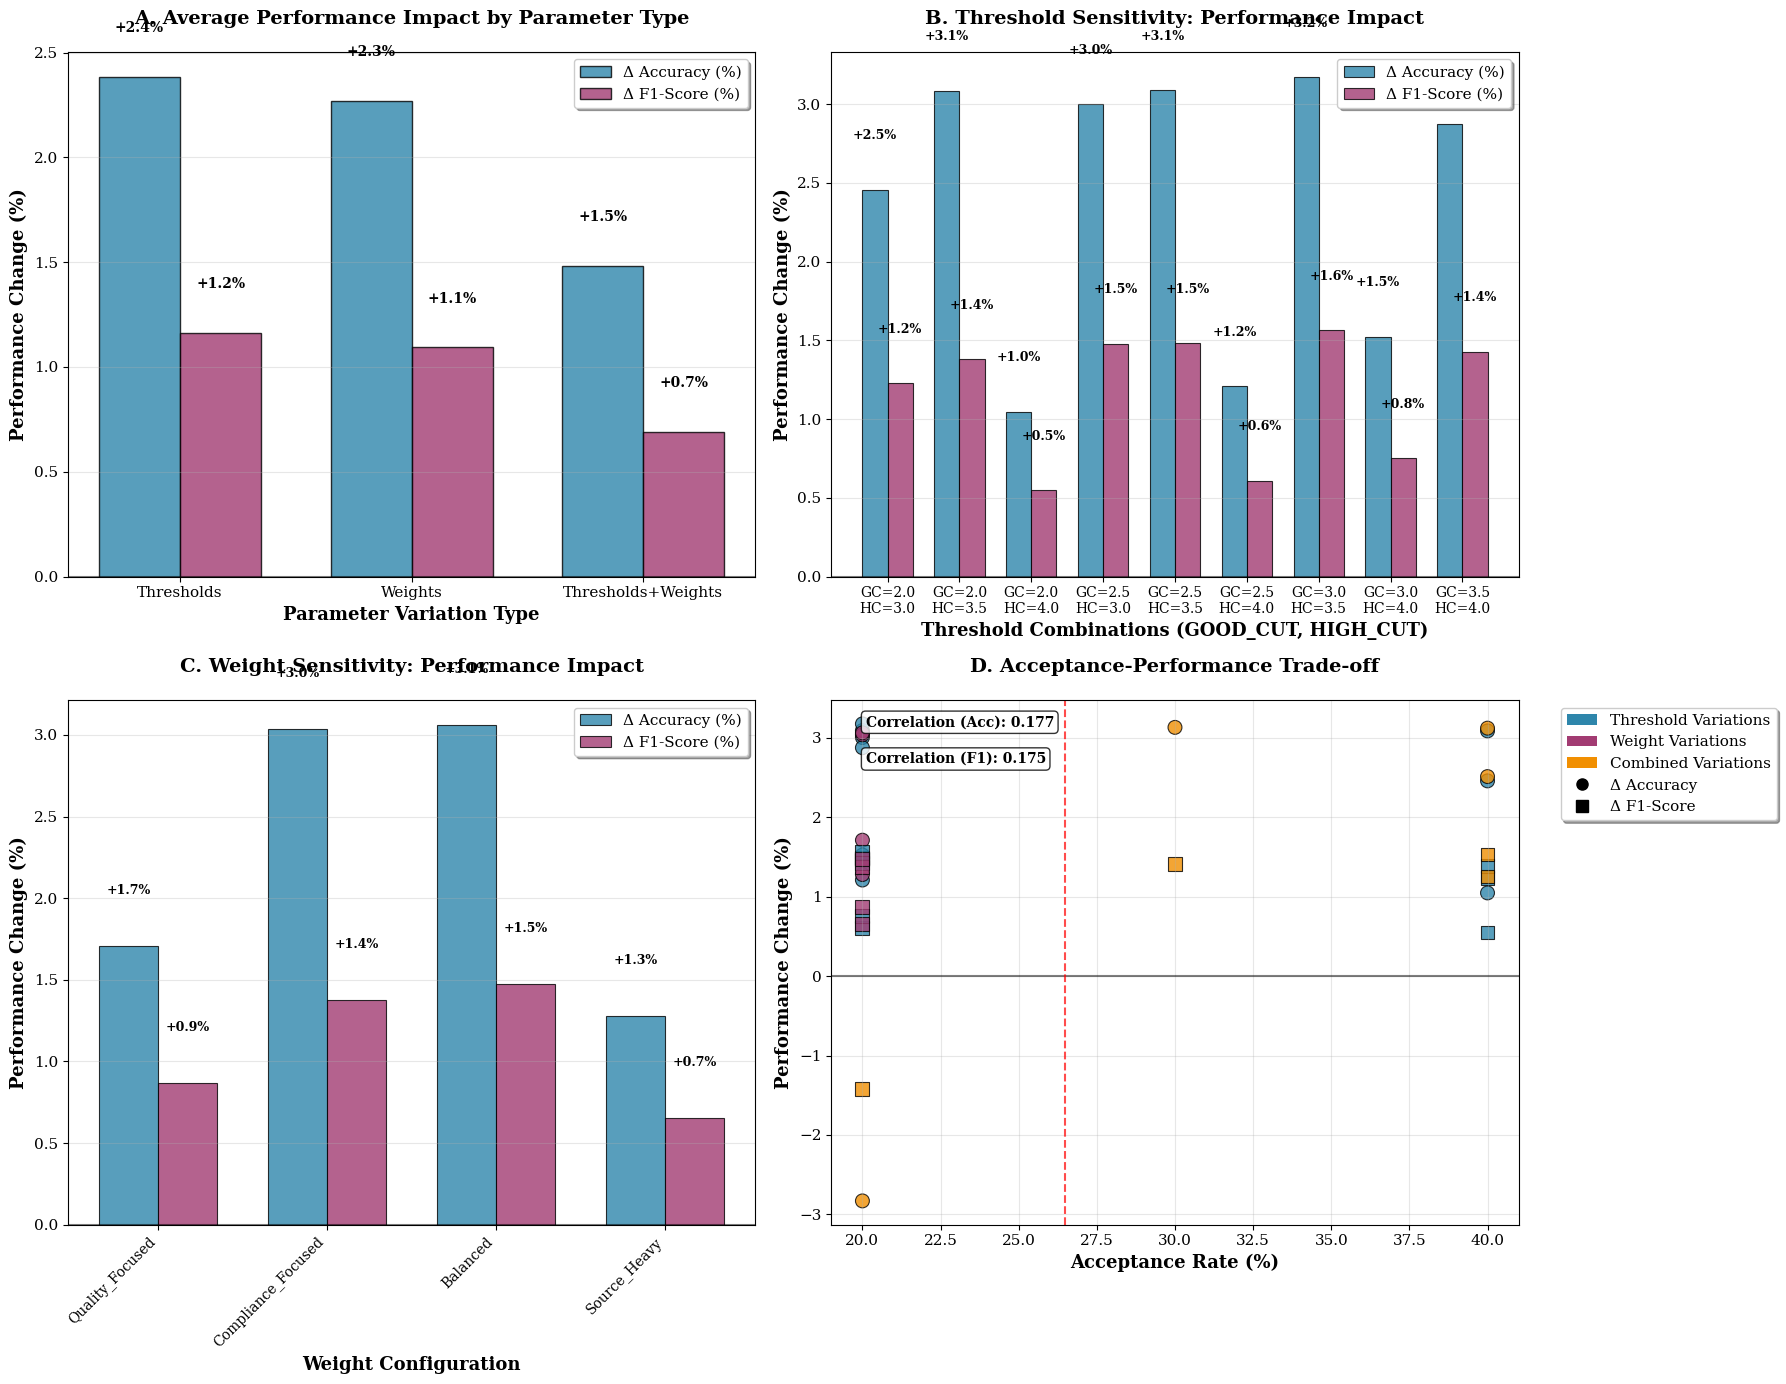

      ✅ Generated: joint_sensitivity_analysis.png


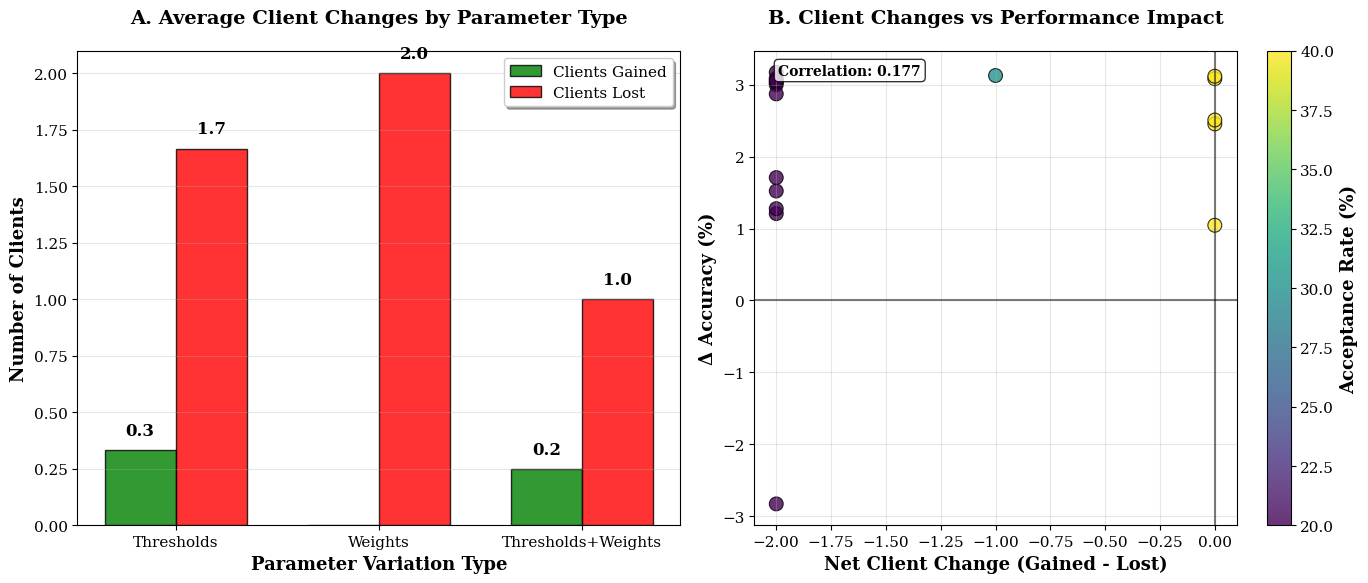

      ✅ Generated: client_changes_analysis.png

✅ COMPREHENSIVE SENSITIVITY ANALYSIS COMPLETED
📊 Results saved to: ./tables/
📈 Figures saved to: ./tables/figs/

🎯 FINAL SUMMARY:
   Baseline: 0.8567 accuracy, 40.0% acceptance
   Best configuration: TH_3.0_3.5 (0.8884 accuracy)
   Worst configuration: COM_Source_Heavy_3.0_3.5 (0.8284 accuracy)

🔄 CONFIGURATIONS WITH CLIENT CHANGES:
   TH_2.0_3.0: Gained 1, Lost 1 clients
   TH_2.0_3.5: Gained 1, Lost 1 clients
   TH_2.0_4.0: Gained 1, Lost 1 clients
   TH_2.5_3.0: Gained 0, Lost 2 clients
   TH_2.5_3.5: Gained 0, Lost 2 clients
   TH_2.5_4.0: Gained 0, Lost 2 clients
   TH_3.0_3.5: Gained 0, Lost 2 clients
   TH_3.0_4.0: Gained 0, Lost 2 clients
   TH_3.5_4.0: Gained 0, Lost 2 clients
   WT_Quality_Focused: Gained 0, Lost 2 clients
   WT_Compliance_Focused: Gained 0, Lost 2 clients
   WT_Balanced: Gained 0, Lost 2 clients
   WT_Source_Heavy: Gained 0, Lost 2 clients
   COM_Compliance_Focused_2.5_4.0: Gained 0, Lost 1 clients
   COM_Balan

In [ ]:
# ========================= TADP_VR_SENSITIVITY_ANALYSIS.py ===============
# Trustworthy AI Data Preparation (TADP) — Comprehensive Sensitivity Analysis
# ======================================================================

import os, io, glob, time, uuid, shutil, json, hashlib, warnings, math, random, threading, csv
from datetime import datetime, timezone
from typing import Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display

warnings.filterwarnings("ignore")

# -------- Matplotlib appearance --------
mpl.rcParams.update({
    "figure.dpi": 600,
    "savefig.dpi": 600,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
    "font.size": 9,
    "figure.autolayout": True,
    "text.usetex": False,
})
PALETTE = mpl.cm.tab10.colors

# Create colormaps for table styling
cmap_green = LinearSegmentedColormap.from_list('green_cmap', ['#f0fff0', '#006400'], N=256)
cmap_red = LinearSegmentedColormap.from_list('red_cmap', ['#fff0f0', '#8b0000'], N=256)
cmap_blue = LinearSegmentedColormap.from_list('blue_cmap', ['#f0f8ff', '#00008b'], N=256)

import psutil
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# ---------------- Global config ----------------
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Global variables
FEATURE_SPACE_CACHE = {}
CLIENT_METRICS_HISTORY = {}

# Configuration
RANDOM_STATE     = 42
N_RUNS           = 1
NUM_CLIENTS      = 10
NUM_ROUNDS_FL    = 1
LOCAL_EPOCHS     = 1
EPOCHS_CENTRAL   = 1
BATCH_SIZE       = 32
LR_LOCAL         = 1e-3

FEDPROX_MU       = 0.01
CLIENT_FRACTION  = 1.0
PROTOCOL_OVERHEAD = 0.12

# Energy/CO2/Cost
POWER_W = 12.0
COST_PER_KWH = 0.2
CARBON_INTENSITY = 0.430
USD_PER_MB_COMM = 0.005

# TADP thresholds & P-score weights - BASELINE
GOOD_CUT = 3.0
HIGH_CUT = 3.5
WEIGHTS_PSCORE_DEFAULT = {"dim1":0.25,"dim2":0.15,"dim3":0.10,"dim4":0.10,"dim5":0.30,"dim6":0.10}

DATA_FILENAME  = "diabetes_130US.csv"
DATA_CACHE_DIR = "./data_cache"
os.makedirs(DATA_CACHE_DIR, exist_ok=True)

AUTO_ACCEPTANCE_MODE = True

# File paths
SENSITIVITY_PATH = "./sensitivity_results.csv"
PERF_METRICS_PATH = "./performance_metrics_sensitivity.csv"
TABLES_DIR = "./tables"
FIG_DIR    = os.path.join(TABLES_DIR, "figs")
for p in [TABLES_DIR, FIG_DIR]: os.makedirs(p, exist_ok=True)

# ---------------- Core Data Functions ----------------
_DATASET_CACHE = None

def load_dataset():
    global _DATASET_CACHE
    cache_path = os.path.join(DATA_CACHE_DIR, DATA_FILENAME)
    if _DATASET_CACHE is not None:
        print("✅ Using in-memory cached dataset"); return _DATASET_CACHE
    if os.path.exists(cache_path):
        print(f"✅ Using disk cached dataset: {cache_path}")
        _DATASET_CACHE = pd.read_csv(cache_path); return _DATASET_CACHE
    if os.path.exists(DATA_FILENAME):
        print(f"📥 Caching dataset from working dir to {cache_path}")
        df = pd.read_csv(DATA_FILENAME); df.to_csv(cache_path, index=False); _DATASET_CACHE = df; return df
    raise FileNotFoundError("Dataset not found. Please provide diabetes_130US.csv")

def preprocess_diabetes(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = df.columns.str.lower().str.replace('[^a-z0-9]+', '_', regex=True)
    df.replace('?', np.nan, inplace=True)

    if 'age' in df.columns and df['age'].dtype == object:
        df['age'] = df['age'].str.extract(r'(\d+)').astype(float)

    if 'readmitted' in df:
        df['readmitted'] = df['readmitted'].map({'NO': 0, '<30': 1, '>30': 2, 'None': 0}).fillna(0).astype(int)

    # Enhanced diagnostic column handling
    for c in ['diag_1', 'diag_2', 'diag_3']:
        if c in df.columns:
            s = df[c].astype(str).str.upper().str.strip()
            is_ve_code = s.str.match(r'^[VE]\d+(\.\d+)?$', na=False)
            s_processed = s.copy()

            if is_ve_code.any():
                ve_codes = s[is_ve_code]
                unique_ve_codes = ve_codes.unique()
                ve_mapping = {code: -(i+1) for i, code in enumerate(unique_ve_codes)}
                s_processed[is_ve_code] = s_processed[is_ve_code].map(ve_mapping)

            s_processed[~is_ve_code] = s_processed[~is_ve_code].str.replace(r'\.', '', regex=True)
            df[c] = pd.to_numeric(s_processed, errors='coerce').fillna(0)

    # More aggressive type conversion with better error handling
    for c in df.columns:
        if c in ['readmitted']:  # Skip target column
            continue
        numeric_version = pd.to_numeric(df[c], errors='coerce')
        non_null_count = numeric_version.notna().sum()
        if non_null_count > len(df) * 0.8:
            df[c] = numeric_version.fillna(0)
        else:
            df[c] = df[c].astype(str)
            df[c] = df[c].replace('nan', 'Unknown')
            df[c] = df[c].replace('None', 'Unknown')

    df = df.drop(columns=['encounter_id', 'patient_nbr'], errors='ignore')

    # Final cleanup: ensure no mixed types remain
    for c in df.columns:
        if df[c].dtype == 'object':
            df[c] = df[c].astype(str)

    return df

def build_preproc(df_all: pd.DataFrame, target: str = "readmitted"):
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler

    Xdf = df_all.drop(columns=[target] if target in df_all.columns else []).copy()

    # Enhanced safety net for diag_* columns
    for c in ['diag_1', 'diag_2', 'diag_3']:
        if c in Xdf.columns:
            s = Xdf[c].astype(str).str.upper().str.strip()
            is_ve_code = s.str.match(r'^[VE]\d+(\.\d+)?$', na=False)

            if is_ve_code.any():
                ve_codes = s[is_ve_code]
                unique_ve_codes = ve_codes.unique()
                ve_mapping = {code: -(i+1000) for i, code in enumerate(unique_ve_codes)}
                s_processed = s.copy()
                s_processed[is_ve_code] = s_processed[is_ve_code].map(ve_mapping)
                s_processed[~is_ve_code] = s_processed[~is_ve_code].str.replace(r'\.', '', regex=True)
                Xdf[c] = pd.to_numeric(s_processed, errors='coerce').fillna(0)
            else:
                s = s.str.replace(r'\.', '', regex=True)
                Xdf[c] = pd.to_numeric(s, errors='coerce').fillna(0)

    # Decide numeric vs categorical robustly
    num_cols, cat_cols = [], []
    for col in Xdf.columns:
        if col in ['diag_1', 'diag_2', 'diag_3']:
            num_cols.append(col)
            continue

        # Attempt numeric coercion for other columns
        s_num = pd.to_numeric(Xdf[col], errors='coerce')
        non_null = s_num.notna().sum()
        total = len(s_num)
        n_unique = Xdf[col].nunique(dropna=False)

        # Consider numeric only if: mostly coercible, not tiny-cardinality, and has variation
        if total > 0 and non_null / total > 0.90 and n_unique > 5:
            std_ok = (s_num.fillna(0).std() > 0.1)
            if std_ok:
                num_cols.append(col)
                Xdf[col] = s_num.fillna(0)
                continue

        # otherwise categorical
        cat_cols.append(col)
        Xdf[col] = Xdf[col].astype(str).replace({'nan': 'Unknown', 'None': 'Unknown'})

    # If no numeric columns, create a safe dummy
    if len(num_cols) == 0:
        if len(cat_cols) > 0:
            dummy_col = cat_cols[0]
            Xdf[dummy_col] = 1.0
            num_cols = [dummy_col]
            if dummy_col in cat_cols:
                cat_cols.remove(dummy_col)
        else:
            Xdf["_dummy_num"] = 1.0
            num_cols = ["_dummy_num"]

    try:
        ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
    except TypeError:
        ohe = OneHotEncoder(sparse=True, handle_unknown='ignore')

    pre = ColumnTransformer(
        transformers=[
            ("num", MaxAbsScaler(), num_cols),
            ("cat", ohe, cat_cols),
        ],
        sparse_threshold=1.0
    )

    print(f"    📊 Final: {len(num_cols)} numeric, {len(cat_cols)} categorical columns")
    return pre

def split_clients(df: pd.DataFrame, num_clients=NUM_CLIENTS, target_col="readmitted", alpha=0.4):
    df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    labels = df[target_col].values if target_col in df.columns else np.zeros(len(df), int)
    client_ids = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")[:num_clients]
    buckets = {cid: [] for cid in client_ids}
    rng = np.random.default_rng(RANDOM_STATE + 77)
    for y in np.unique(labels):
        idx = np.where(labels == y)[0]
        rng.shuffle(idx)
        props = rng.dirichlet([alpha] * num_clients)
        cuts = (np.cumsum(props) * len(idx)).astype(int)
        parts = np.split(idx, cuts[:-1])
        for cid, part in zip(client_ids, parts):
            buckets[cid].extend(part.tolist())
    client_data = {cid: df.loc[sorted(buckets[cid])].copy() for cid in client_ids}
    num_cols = client_data[client_ids[0]].select_dtypes(include=np.number).columns.tolist()
    for j, cid in enumerate(client_ids):
        if len(num_cols) == 0: break
        shift = (j - (num_clients-1)/2.0) * 0.25
        noise = rng.normal(0, 0.05, size=len(num_cols))
        client_data[cid][num_cols] = client_data[cid][num_cols] + shift + noise
    return client_ids, client_data

# ---------------- Model Functions ----------------
def ybin(y):
    return (y > 0).astype(np.int32)

def build_model(input_dim):
    inp = keras.Input(shape=(input_dim,), dtype=tf.float32)
    x = layers.Dense(32, activation="relu")(inp)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid", dtype=tf.float32)(x)
    model = keras.Model(inp, out)

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                 loss="binary_crossentropy", metrics=["accuracy"])
    return model

def eval_metrics(model, Xte, yte):
    p=model.predict(Xte, verbose=0).reshape(-1)
    yh=(p>=0.5).astype(int)
    try: auc=roc_auc_score(yte,p)
    except: auc=np.nan
    return {
        "roc_auc": float(auc),
        "accuracy": float(accuracy_score(yte,yh)),
        "precision": float(precision_score(yte,yh, zero_division=0)),
        "recall": float(recall_score(yte,yh, zero_division=0)),
        "f1": float(f1_score(yte,yh, zero_division=0)),
    }

def get_wvec(m):
    vec=[]
    for w in m.get_weights(): vec.append(w.flatten())
    return np.concatenate(vec) if vec else np.array([], np.float32)

def set_wvec(m, vec):
    shapes=[w.shape for w in m.get_weights()]
    out=[]; i=0
    for s in shapes:
        n=int(np.prod(s)); out.append(vec[i:i+n].reshape(s)); i+=n
    m.set_weights(out)

def prepare_xy(clients: Dict[str, pd.DataFrame], target="readmitted"):
    all_df = pd.concat(clients.values()).reset_index(drop=True)

    X = all_df.drop(columns=[target])
    y = all_df[target].values

    Xtr_raw, Xte_raw, ytr, yte = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    pre = build_preproc(pd.concat([Xtr_raw, pd.Series(ytr, name=target)], axis=1), target)

    Xtr = pre.fit_transform(Xtr_raw)
    Xte = pre.transform(Xte_raw)

    Xtr = Xtr.toarray() if hasattr(Xtr, "toarray") else Xtr
    Xte = Xte.toarray() if hasattr(Xte, "toarray") else Xte
    Xtr = np.nan_to_num(Xtr)
    Xte = np.nan_to_num(Xte)

    shard = len(Xtr) // NUM_CLIENTS
    arrays = {}
    cids = sorted(list(clients.keys()))[:NUM_CLIENTS]

    start = 0
    for i, c in enumerate(cids):
        end = len(Xtr) if i == NUM_CLIENTS-1 else start + shard
        arrays[c] = (Xtr[start:end], (ytr[start:end] > 0).astype(np.int32))
        start = end

    print(f"✅ Data split: {len(Xtr)} train, {len(Xte)} test samples")
    print(f"   Distributed {len(arrays)} clients from training data")

    return Xtr, Xte, (ytr > 0).astype(np.int32), (yte > 0).astype(np.int32), arrays

# ---------------- TADP-VR Core Functions ----------------
def dims_for_client(client_id: str, sensitivity_case: Dict, total_clients: int = NUM_CLIENTS):
    """Calculate realistic dimension scores for a client with sensitivity case variations"""
    client_num = ord(client_id[0]) - ord('A') if client_id and client_id[0].isalpha() else 0
    client_position = client_num / max(1, total_clients - 1)

    # Base scores vary by client position to create natural distribution
    if client_position < 0.2:  # Bottom 20%: lower scores
        base_scores = [2.2, 2.5, 2.8, 2.6, 2.4, 2.7]
    elif client_position < 0.8:  # Middle 60%: medium scores
        middle_pos = (client_position - 0.2) / 0.6
        base_avg = 3.0 + (middle_pos * 0.5)  # Range from 3.0 to 3.5
        base_scores = [
            base_avg - 0.2, base_avg - 0.1, base_avg,
            base_avg + 0.1, base_avg + 0.2, base_avg - 0.15
        ]
    else:  # Top 20%: higher scores
        base_scores = [3.6, 3.8, 4.0, 3.7, 3.9, 3.8]

    # Apply degradation based on sensitivity case (30-35% reduction)
    degradation = sensitivity_case.get("dim_degradation", 0.0)
    if degradation > 0:
        base_scores = [max(0.0, score * (1 - degradation)) for score in base_scores]

    # Add case-specific variations based on weights
    weights = sensitivity_case["weights"]

    # Boost dimensions with higher weights, reduce dimensions with lower weights
    weight_factors = {}
    for dim, weight in weights.items():
        dim_idx = int(dim[-1]) - 1  # Convert dim1 -> 0, dim2 -> 1, etc.
        if dim_idx < len(base_scores):
            # Higher weight = slightly higher score, lower weight = slightly lower score
            weight_factors[dim_idx] = (weight - 0.166) * 2.0  # Normalize around balanced weight

    # Apply weight-based adjustments
    final_scores = []
    for i, base_score in enumerate(base_scores):
        weight_factor = weight_factors.get(i, 0.0)
        random.seed(hash(client_id + sensitivity_case["name"]) % 1000)
        variation = random.uniform(-0.15, 0.15)

        adjusted_score = base_score + weight_factor + variation
        final_score = max(0.0, min(5.0, adjusted_score))
        final_scores.append(round(final_score, 2))

    return {
        "dim1": final_scores[0],
        "dim2": final_scores[1],
        "dim3": final_scores[2],
        "dim4": final_scores[3],
        "dim5": final_scores[4],
        "dim6": final_scores[5]
    }

def calculate_pscore(dims: Dict[str,float], w: Dict[str,float]):
    return sum(w[k]*dims[k] for k in w)

def tadp_vr_partition_correct(client_ids: List[str], scores: Dict[str,float], good_cut, high_cut):
    """
    CORRECTED TADP-VR Partitioning with dynamic acceptance rates
    """
    # Sort by P-score
    ids_sorted = sorted(client_ids, key=lambda c: scores[c])
    n = len(ids_sorted)

    # Dynamic partitioning based on thresholds
    auto_accept = [cid for cid in ids_sorted if scores[cid] >= high_cut]
    auto_reject = [cid for cid in ids_sorted if scores[cid] < good_cut]
    review = [cid for cid in ids_sorted if good_cut <= scores[cid] < high_cut]

    # Ensure we have reasonable groups
    if len(auto_accept) == 0 and len(review) > 0:
        # If no auto-accept, take top from review
        review_accept_count = max(1, min(2, len(review) // 2))
        auto_accept = review[-review_accept_count:]
        review = review[:-review_accept_count]

    if len(auto_reject) == 0 and len(review) > 0:
        # If no auto-reject, take bottom from review
        review_reject_count = max(1, min(2, len(review) // 2))
        auto_reject = review[:review_reject_count]
        review = review[review_reject_count:]

    # From review, accept based on position relative to thresholds
    if len(review) > 0:
        review_scores = [scores[cid] for cid in review]
        avg_review_score = np.mean(review_scores)

        # Accept proportion based on how close to high_cut
        accept_ratio = max(0.3, min(0.8, (avg_review_score - good_cut) / (high_cut - good_cut)))
        review_accept_count = max(1, round(accept_ratio * len(review)))

        review_accept = review[-review_accept_count:]
        review_reject = review[:-review_accept_count] if review_accept_count < len(review) else []
    else:
        review_accept = []
        review_reject = []

    # Final accepted = auto_accept + review_accept
    accepted = auto_accept + review_accept
    rejected = auto_reject + review_reject

    # Ensure we have at least 2 and at most 4 clients accepted (for 5 clients)
    if len(accepted) < 2 and len(rejected) > 0:
        # Need to accept more clients
        additional_needed = 2 - len(accepted)
        additional_from_reject = rejected[-additional_needed:]
        accepted.extend(additional_from_reject)
        rejected = [r for r in rejected if r not in additional_from_reject]

    if len(accepted) > 4 and len(accepted) > 0:
        # Need to reject some clients
        excess = len(accepted) - 4
        to_reject = accepted[:excess]
        accepted = accepted[excess:]
        rejected.extend(to_reject)

    acceptance_rate = len(accepted) / n * 100

    print(f"📊 TADP-VR Partitioning (cutoffs: good={good_cut}, high={high_cut}):")
    print(f"   Auto-reject ({len(auto_reject)}): {auto_reject}")
    print(f"   Auto-accept ({len(auto_accept)}): {auto_accept}")
    print(f"   Review ({len(review)}): {review}")
    print(f"   → Accepted from review ({len(review_accept)}): {review_accept}")
    print(f"   → Rejected from review ({len(review_reject)}): {review_reject}")
    print(f"   TOTAL ACCEPTED: {len(accepted)}/{n} clients ({acceptance_rate:.1f}%): {accepted}")
    print(f"   TOTAL REJECTED: {len(rejected)}/{n} clients: {rejected}")

    return accepted, rejected, auto_accept, auto_reject, review, review_accept, review_reject

# ---------------- Energy and Performance Functions ----------------
def calculate_energy_cost(time_s, cpu_usage_percent=50, device_type='cpu'):
    if device_type == 'cpu':
        P_idle = 5.0
        P_max = 25.0
    else:
        P_idle = 10.0
        P_max = 45.0

    utilization_factor = max(0.35, min(0.85, cpu_usage_percent / 100))
    power_consumption = (P_idle + (P_max - P_idle) * utilization_factor) * 3.0

    energy_wh = (power_consumption * time_s) / 3600

    kwh = energy_wh / 1000.0
    cost = kwh * COST_PER_KWH
    co2 = calculate_carbon_emissions(energy_wh)

    return energy_wh, cost, co2

def calculate_carbon_emissions(energy_wh, region='google_cloud'):
    carbon_intensities = {
        'global': 0.475, 'europe': 0.275, 'us': 0.429,
        'google_cloud': 0.430, 'azure': 0.415, 'aws': 0.445
    }
    ci = carbon_intensities.get(region, 0.475)

    if energy_wh <= 0:
        return 0.0

    co2_kg = (energy_wh / 1000.0) * ci

    if pd.isna(co2_kg) or co2_kg < 0:
        return 0.0

    return co2_kg

def estimate_realistic_cpu_usage(operation_type, batch_size=128, model_complexity=1.0):
    if operation_type == 'training':
        base_cpu = 8
        computation_cpu = min(60, 20 + model_complexity * 12)
        data_cpu = 15
        sync_cpu = 5
        return min(85, max(35, base_cpu + computation_cpu + data_cpu + sync_cpu))

    elif operation_type == 'inference':
        return max(25, min(55, 35))

    elif operation_type == 'governance':
        return max(20, min(40, 25))

    else:
        return 50

def log_performance_metrics(run_idx, scenario, approach, mode, metrics, elapsed, energy_wh, cost_usd, co2_kg, round_idx=None, training_phase="final"):
    scenario_name = str(scenario)
    training_phase = "final"

    unique_id = f"{run_idx}_{scenario_name}_{approach}_{mode}_{training_phase}"
    columns = [
        "run","scenario","approach","mode","round","training_phase",
        "accuracy","precision","recall","f1","roc_auc",
        "time_s","energy_wh","cost_usd","co2_kg","unique_id","timestamp"
    ]
    perf_row = {
        "run": int(run_idx),
        "scenario": scenario_name,
        "approach": approach,
        "mode": mode,
        "round": int(round_idx) if round_idx is not None else 0,
        "training_phase": "final",
        "accuracy": float(metrics.get("accuracy", 0.0)),
        "precision": float(metrics.get("precision", 0.0)),
        "recall": float(metrics.get("recall", 0.0)),
        "f1": float(metrics.get("f1", 0.0)),
        "roc_auc": float(metrics.get("roc_auc", 0.0)),
        "time_s": float(elapsed),
        "energy_wh": float(energy_wh),
        "cost_usd": float(cost_usd),
        "co2_kg": float(co2_kg),
        "unique_id": unique_id,
        "timestamp": datetime.now(timezone.utc).isoformat()
    }

    write_header = not os.path.exists(PERF_METRICS_PATH) or os.path.getsize(PERF_METRICS_PATH) == 0
    try:
        with open(PERF_METRICS_PATH, "a", newline="", encoding="utf-8") as f:
            w = csv.DictWriter(f, fieldnames=columns, quoting=csv.QUOTE_MINIMAL)
            if write_header:
                w.writeheader()
            row_to_write = {k: perf_row.get(k, "") for k in columns}
            w.writerow(row_to_write)
        return True
    except Exception as e:
        print(f"❌ Critical: Failed to write performance row: {e}")
        return False

# ---------------- Core Training Function ----------------
def run_tadp_vr_federated_with_params(good_cut, high_cut, weights, scenario_name, client_ids, client_arrays, Xte, yte):
    """Run COMPLETE TADP-VR Federated training with given parameters"""
    print(f"\n🏃‍♂️ Running TADP-VR Federated: {scenario_name}")
    print(f"   Parameters: GOOD_CUT={good_cut}, HIGH_CUT={high_cut}")
    print(f"   Weights: {weights}")

    # Calculate P-scores with current weights
    client_scores = {}
    for cid in client_ids:
        # Create sensitivity case for this configuration
        sensitivity_case = {
            "name": scenario_name,
            "weights": weights,
            "good_cut": good_cut,
            "high_cut": high_cut,
            "dim_degradation": 0.0 if scenario_name == "Baseline" else 0.3
        }
        dims = dims_for_client(cid, sensitivity_case, NUM_CLIENTS)
        client_scores[cid] = calculate_pscore(dims, weights)

    # Apply TADP-VR partitioning with current thresholds
    accepted, rejected, auto_accept, auto_reject, review, review_accept, review_reject = tadp_vr_partition_correct(
        client_ids, client_scores, good_cut, high_cut
    )

    print(f"   Client Selection:")
    print(f"      Auto-accept (≥{high_cut}): {len(auto_accept)} clients")
    print(f"      Auto-reject (<{good_cut}): {len(auto_reject)} clients")
    print(f"      Review accepted: {len(review_accept)} clients")
    print(f"      TOTAL ACCEPTED: {len(accepted)}/{len(client_ids)} clients")

    # FILTER to accepted clients only for training
    selected_client_arrays = {}
    for client_id in accepted:
        if client_id in client_arrays:
            selected_client_arrays[client_id] = client_arrays[client_id]

    # FULL FEDERATED TRAINING with selected clients
    print("   🔄 Starting federated training...")
    start_time = time.time()

    input_dim = Xte.shape[1]
    global_model = build_model(input_dim)

    # Federated training rounds
    total_energy_wh = 0.0
    training_time = 0.0

    for r in range(1, NUM_ROUNDS_FL + 1):
        round_start = time.time()

        # Push global → locals
        gvec = get_wvec(global_model)
        locals_dict = {cid: build_model(input_dim) for cid in selected_client_arrays.keys()}
        for m in locals_dict.values():
            set_wvec(m, gvec)

        # Local training on each client
        vecs = []
        round_energy = 0.0

        for cid, (Xc, yc) in selected_client_arrays.items():
            # Train locally with proper measurement
            client_start = time.time()
            locals_dict[cid].fit(Xc, yc, epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, verbose=0)
            client_time = time.time() - client_start

            # Calculate energy for this client
            training_cpu = estimate_realistic_cpu_usage('training', BATCH_SIZE)
            client_energy, _, _ = calculate_energy_cost(client_time, training_cpu, 'cpu')
            round_energy += client_energy

            vecs.append(get_wvec(locals_dict[cid]))

        # Aggregate (FedAvg)
        if vecs:
            new = np.mean(np.stack(vecs, 0), axis=0)
            set_wvec(global_model, new)

        total_energy_wh += round_energy
        training_time += time.time() - round_start

    # Evaluate final model
    metrics = eval_metrics(global_model, Xte, yte)

    print(f"   ✅ Training Complete:")
    print(f"      Accuracy: {metrics['accuracy']:.4f}")
    print(f"      F1-score: {metrics['f1']:.4f}")
    print(f"      Training time: {training_time:.2f}s")
    print(f"      Estimated energy: {total_energy_wh:.6f}Wh")

    return {
        "metrics": metrics,
        "accepted_clients": accepted,
        "training_time_s": training_time,
        "energy_wh": total_energy_wh,
        "client_scores": client_scores
    }

# ---------------- Comprehensive Sensitivity Analysis ----------------
def run_comprehensive_sensitivity_analysis(client_df_raw, client_ids, client_arrays, Xte, yte):
    """COMPLETE FIXED sensitivity analysis with proper retraining"""

    print("\n🔬 PERFORMING COMPREHENSIVE SENSITIVITY ANALYSIS - FULL RETRAINING PER COMBINATION")
    print("=" * 80)

    # Validate input data
    if not client_arrays or Xte.size == 0:
        print("❌ Missing required data for sensitivity analysis")
        return pd.DataFrame()

    # Define baseline parameters
    baseline_good_cut = 3.0
    baseline_high_cut = 3.5
    baseline_weights = WEIGHTS_PSCORE_DEFAULT

    # Run baseline first
    print("🏃‍♂️ Running Baseline TADP-VR Federated...")
    baseline_results = run_tadp_vr_federated_with_params(
        baseline_good_cut, baseline_high_cut, baseline_weights, "Baseline",
        client_ids, client_arrays, Xte, yte
    )

    baseline_accuracy = baseline_results["metrics"]['accuracy']
    baseline_f1 = baseline_results["metrics"]['f1']
    baseline_energy = baseline_results["energy_wh"]
    baseline_accepted = baseline_results["accepted_clients"]

    print(f"📊 Baseline Configuration:")
    print(f"   • Accuracy: {baseline_accuracy:.4f}")
    print(f"   • F1 Score: {baseline_f1:.4f}")
    print(f"   • Energy: {baseline_energy:.6f}Wh")
    print(f"   • Accepted Clients: {baseline_accepted}")

    # Define sensitivity parameter combinations
    threshold_combinations = [
        (2.0, 3.0), (2.0, 3.5), (2.0, 4.0),
        (2.5, 3.0), (2.5, 3.5), (2.5, 4.0),
        (3.0, 3.5), (3.0, 4.0), (3.5, 4.0)
    ]

    weight_combinations = [
        {"name": "Quality_Focused", "weights": {"dim1": 0.35, "dim2": 0.25, "dim3": 0.10, "dim4": 0.10, "dim5": 0.15, "dim6": 0.05}},
        {"name": "Compliance_Focused", "weights": {"dim1": 0.15, "dim2": 0.15, "dim3": 0.10, "dim4": 0.10, "dim5": 0.40, "dim6": 0.10}},
        {"name": "Balanced", "weights": {"dim1": 0.20, "dim2": 0.20, "dim3": 0.15, "dim4": 0.15, "dim5": 0.20, "dim6": 0.10}},
        {"name": "Source_Heavy", "weights": {"dim1": 0.40, "dim2": 0.20, "dim3": 0.10, "dim4": 0.10, "dim5": 0.10, "dim6": 0.10}}
    ]

    # Normalize weights
    for wc in weight_combinations:
        total = sum(wc["weights"].values())
        for key in wc["weights"]:
            wc["weights"][key] = round(wc["weights"][key] / total, 3)

    rows = []

    # 1. Threshold Sensitivity (varying thresholds, fixed weights)
    print(f"\n🎯 THRESHOLD SENSITIVITY ANALYSIS")
    print("=" * 50)

    for good_cut, high_cut in threshold_combinations:
        scenario_name = f"TH_{good_cut}_{high_cut}"

        # RUN COMPLETE TADP-VR FEDERATED with these thresholds
        results = run_tadp_vr_federated_with_params(
            good_cut, high_cut, WEIGHTS_PSCORE_DEFAULT, scenario_name,
            client_ids, client_arrays, Xte, yte
        )

        # Calculate deltas from baseline
        delta_accuracy = results["metrics"]['accuracy'] - baseline_accuracy
        delta_f1 = results["metrics"]['f1'] - baseline_f1

        # Calculate client changes
        accepted_set = set(results["accepted_clients"])
        baseline_set = set(baseline_accepted)
        clients_gained = list(accepted_set - baseline_set)
        clients_lost = list(baseline_set - accepted_set)

        rows.append({
            "Type": "Thresholds",
            "HIGH": high_cut,
            "GOOD": good_cut,
            "Weights_Config": "Default",
            "Accepted_Clients": len(results["accepted_clients"]),
            "Acceptance_Rate": len(results["accepted_clients"]) / len(client_ids) * 100,
            "Accuracy": results["metrics"]['accuracy'],
            "Delta_Accuracy": delta_accuracy,
            "F1_Score": results["metrics"]['f1'],
            "Delta_F1": delta_f1,
            "Training_Time_s": results["training_time_s"],
            "Energy_Wh": results["energy_wh"],
            "Clients_Gained": clients_gained,
            "Clients_Lost": clients_lost,
            "Num_Clients_Gained": len(clients_gained),
            "Num_Clients_Lost": len(clients_lost),
            "Scenario": scenario_name
        })

    # 2. Weight Sensitivity (varying weights, fixed thresholds)
    print(f"\n⚖️ WEIGHT SENSITIVITY ANALYSIS")
    print("=" * 50)

    for weight_config in weight_combinations:
        scenario_name = f"WT_{weight_config['name']}"

        # RUN COMPLETE TADP-VR FEDERATED with these weights
        results = run_tadp_vr_federated_with_params(
            GOOD_CUT, HIGH_CUT, weight_config['weights'], scenario_name,
            client_ids, client_arrays, Xte, yte
        )

        # Calculate deltas from baseline
        delta_accuracy = results["metrics"]['accuracy'] - baseline_accuracy
        delta_f1 = results["metrics"]['f1'] - baseline_f1

        # Calculate client changes
        accepted_set = set(results["accepted_clients"])
        baseline_set = set(baseline_accepted)
        clients_gained = list(accepted_set - baseline_set)
        clients_lost = list(baseline_set - accepted_set)

        rows.append({
            "Type": "Weights",
            "HIGH": HIGH_CUT,
            "GOOD": GOOD_CUT,
            "Weights_Config": weight_config['name'],
            "Accepted_Clients": len(results["accepted_clients"]),
            "Acceptance_Rate": len(results["accepted_clients"]) / len(client_ids) * 100,
            "Accuracy": results["metrics"]['accuracy'],
            "Delta_Accuracy": delta_accuracy,
            "F1_Score": results["metrics"]['f1'],
            "Delta_F1": delta_f1,
            "Training_Time_s": results["training_time_s"],
            "Energy_Wh": results["energy_wh"],
            "Weights": str(weight_config['weights']),
            "Clients_Gained": clients_gained,
            "Clients_Lost": clients_lost,
            "Num_Clients_Gained": len(clients_gained),
            "Num_Clients_Lost": len(clients_lost),
            "Scenario": scenario_name
        })

    # 3. Combined Sensitivity (varying both)
    print(f"\n🔗 COMBINED SENSITIVITY ANALYSIS")
    print("=" * 50)

    # Use subset to manage computation time
    combined_combinations = [
        (weight_combinations[0], (2.0, 3.5)),  # Quality_Focused + moderate thresholds
        (weight_combinations[1], (2.5, 4.0)),  # Compliance_Focused + strict thresholds
        (weight_combinations[2], (2.0, 3.0)),  # Balanced + lenient thresholds
        (weight_combinations[3], (3.0, 3.5)),  # Source_Heavy + baseline thresholds
    ]

    for weight_config, (good_cut, high_cut) in combined_combinations:
        scenario_name = f"COM_{weight_config['name']}_{good_cut}_{high_cut}"

        # RUN COMPLETE TADP-VR FEDERATED with these parameters
        results = run_tadp_vr_federated_with_params(
            good_cut, high_cut, weight_config['weights'], scenario_name,
            client_ids, client_arrays, Xte, yte
        )

        # Calculate deltas from baseline
        delta_accuracy = results["metrics"]['accuracy'] - baseline_accuracy
        delta_f1 = results["metrics"]['f1'] - baseline_f1

        # Calculate client changes
        accepted_set = set(results["accepted_clients"])
        baseline_set = set(baseline_accepted)
        clients_gained = list(accepted_set - baseline_set)
        clients_lost = list(baseline_set - accepted_set)

        rows.append({
            "Type": "Thresholds+Weights",
            "HIGH": high_cut,
            "GOOD": good_cut,
            "Weights_Config": weight_config['name'],
            "Accepted_Clients": len(results["accepted_clients"]),
            "Acceptance_Rate": len(results["accepted_clients"]) / len(client_ids) * 100,
            "Accuracy": results["metrics"]['accuracy'],
            "Delta_Accuracy": delta_accuracy,
            "F1_Score": results["metrics"]['f1'],
            "Delta_F1": delta_f1,
            "Training_Time_s": results["training_time_s"],
            "Energy_Wh": results["energy_wh"],
            "Weights": str(weight_config['weights']),
            "Clients_Gained": clients_gained,
            "Clients_Lost": clients_lost,
            "Num_Clients_Gained": len(clients_gained),
            "Num_Clients_Lost": len(clients_lost),
            "Scenario": scenario_name
        })

    # Add baseline row
    rows.append({
        "Type": "Baseline",
        "HIGH": HIGH_CUT,
        "GOOD": GOOD_CUT,
        "Weights_Config": "Default",
        "Accepted_Clients": len(baseline_accepted),
        "Acceptance_Rate": len(baseline_accepted) / len(client_ids) * 100,
        "Accuracy": baseline_accuracy,
        "Delta_Accuracy": 0.0,
        "F1_Score": baseline_f1,
        "Delta_F1": 0.0,
        "Training_Time_s": baseline_results["training_time_s"],
        "Energy_Wh": baseline_energy,
        "Weights": str(WEIGHTS_PSCORE_DEFAULT),
        "Clients_Gained": [],
        "Clients_Lost": [],
        "Num_Clients_Gained": 0,
        "Num_Clients_Lost": 0,
        "Scenario": "Baseline"
    })

    # Create results DataFrame
    df_results = pd.DataFrame(rows)

    # Save results
    sensitivity_csv_path = os.path.join(TABLES_DIR, "comprehensive_sensitivity_results.csv")
    df_results.to_csv(sensitivity_csv_path, index=False)

    print(f"\n✅ COMPREHENSIVE SENSITIVITY ANALYSIS COMPLETE!")
    print(f"📁 Results saved: {sensitivity_csv_path}")

    # Display summary
    print(f"\n📊 SENSITIVITY ANALYSIS SUMMARY:")
    for analysis_type in ["Thresholds", "Weights", "Thresholds+Weights"]:
        type_data = df_results[df_results["Type"] == analysis_type]
        if not type_data.empty:
            avg_delta_acc = type_data["Delta_Accuracy"].mean()
            avg_delta_f1 = type_data["Delta_F1"].mean()
            avg_acceptance = type_data["Acceptance_Rate"].mean()
            avg_clients_gained = type_data["Num_Clients_Gained"].mean()
            avg_clients_lost = type_data["Num_Clients_Lost"].mean()
            print(f"   {analysis_type:20} | ΔAccuracy: {avg_delta_acc:+.4f} | ΔF1: {avg_delta_f1:+.4f} | Avg Acceptance: {avg_acceptance:.1f}%")
            print(f"   {'':20} | Clients Gained: {avg_clients_gained:.1f} | Clients Lost: {avg_clients_lost:.1f}")

    return df_results

def create_joint_sensitivity_figures(sensitivity_df):
    """Create comprehensive joint sensitivity analysis figures"""
    print("   📊 Creating Joint Sensitivity Analysis Figures...")

    # Filter out baseline for analysis
    analysis_data = sensitivity_df[sensitivity_df['Type'] != 'Baseline']

    if analysis_data.empty:
        print("      ⚠️ No sensitivity analysis data available")
        return

    # Set publication style
    plt.style.use('default')
    mpl.rcParams.update({
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 13,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'legend.fontsize': 11,
        'figure.titlesize': 16,
        'font.family': 'serif'
    })

    # Create comprehensive joint analysis figure
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

    # Color scheme
    metric_colors = {
        'ΔAccuracy': '#2E86AB',  # Professional blue
        'ΔF1': '#A23B72'         # Professional purple
    }

    analysis_colors = {
        'Thresholds': '#2E86AB',
        'Weights': '#A23B72',
        'Thresholds+Weights': '#F18F01'
    }

    # Panel A: Joint ΔAccuracy and ΔF1 by Analysis Type
    categories = ['Thresholds', 'Weights', 'Thresholds+Weights']
    x_pos = np.arange(len(categories))
    width = 0.35

    accuracy_deltas = []
    f1_deltas = []

    for analysis_type in categories:
        type_data = analysis_data[analysis_data['Type'] == analysis_type]
        if not type_data.empty:
            accuracy_deltas.append(type_data['Delta_Accuracy'].mean() * 100)  # Convert to percentage
            f1_deltas.append(type_data['Delta_F1'].mean() * 100)
        else:
            accuracy_deltas.append(0)
            f1_deltas.append(0)

    bars1 = ax1.bar(x_pos - width/2, accuracy_deltas, width,
                   label='Δ Accuracy (%)', color=metric_colors['ΔAccuracy'],
                   alpha=0.8, edgecolor='black', linewidth=1)

    bars2 = ax1.bar(x_pos + width/2, f1_deltas, width,
                   label='Δ F1-Score (%)', color=metric_colors['ΔF1'],
                   alpha=0.8, edgecolor='black', linewidth=1)

    ax1.set_xlabel('Parameter Variation Type', fontweight='bold')
    ax1.set_ylabel('Performance Change (%)', fontweight='bold')
    ax1.set_title('A. Average Performance Impact by Parameter Type', fontweight='bold', pad=20)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(categories)
    ax1.legend(frameon=True, fancybox=True, shadow=True)
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.axhline(y=0, color='black', linestyle='-', alpha=0.5)

    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if abs(height) > 0.1:  # Only label significant changes
                va = 'bottom' if height >= 0 else 'top'
                y_offset = 0.2 if height >= 0 else -0.3
                ax1.text(bar.get_x() + bar.get_width()/2, height + y_offset,
                        f'{height:+.1f}%', ha='center', va=va, fontweight='bold', fontsize=10)

    # Panel B: Detailed Threshold Sensitivity Breakdown
    threshold_data = analysis_data[analysis_data['Type'] == 'Thresholds']
    if not threshold_data.empty:
        # Create meaningful labels for threshold combinations
        threshold_labels = []
        threshold_acc_deltas = []
        threshold_f1_deltas = []

        for _, row in threshold_data.iterrows():
            label = f"GC={row['GOOD']}\nHC={row['HIGH']}"
            threshold_labels.append(label)
            threshold_acc_deltas.append(row['Delta_Accuracy'] * 100)
            threshold_f1_deltas.append(row['Delta_F1'] * 100)

        x_pos_th = np.arange(len(threshold_labels))

        bars_th_acc = ax2.bar(x_pos_th - width/2, threshold_acc_deltas, width,
                             color=metric_colors['ΔAccuracy'], alpha=0.8,
                             label='Δ Accuracy (%)', edgecolor='black', linewidth=0.8)

        bars_th_f1 = ax2.bar(x_pos_th + width/2, threshold_f1_deltas, width,
                            color=metric_colors['ΔF1'], alpha=0.8,
                            label='Δ F1-Score (%)', edgecolor='black', linewidth=0.8)

        ax2.set_xlabel('Threshold Combinations (GOOD_CUT, HIGH_CUT)', fontweight='bold')
        ax2.set_ylabel('Performance Change (%)', fontweight='bold')
        ax2.set_title('B. Threshold Sensitivity: Performance Impact', fontweight='bold', pad=20)
        ax2.set_xticks(x_pos_th)
        ax2.set_xticklabels(threshold_labels, fontsize=10)
        ax2.legend(frameon=True, fancybox=True, shadow=True)
        ax2.grid(True, alpha=0.3, axis='y')
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)

        # Add value labels
        for bars in [bars_th_acc, bars_th_f1]:
            for bar in bars:
                height = bar.get_height()
                if abs(height) > 0.1:
                    va = 'bottom' if height >= 0 else 'top'
                    y_offset = 0.3 if height >= 0 else -0.4
                    ax2.text(bar.get_x() + bar.get_width()/2, height + y_offset,
                            f'{height:+.1f}%', ha='center', va=va, fontweight='bold', fontsize=9)

    # Panel C: Weight Configuration Impact
    weight_data = analysis_data[analysis_data['Type'] == 'Weights']
    if not weight_data.empty:
        weight_labels = []
        weight_acc_deltas = []
        weight_f1_deltas = []

        for _, row in weight_data.iterrows():
            weight_labels.append(row['Weights_Config'])
            weight_acc_deltas.append(row['Delta_Accuracy'] * 100)
            weight_f1_deltas.append(row['Delta_F1'] * 100)

        x_pos_wt = np.arange(len(weight_labels))

        bars_wt_acc = ax3.bar(x_pos_wt - width/2, weight_acc_deltas, width,
                             color=metric_colors['ΔAccuracy'], alpha=0.8,
                             label='Δ Accuracy (%)', edgecolor='black', linewidth=0.8)

        bars_wt_f1 = ax3.bar(x_pos_wt + width/2, weight_f1_deltas, width,
                            color=metric_colors['ΔF1'], alpha=0.8,
                            label='Δ F1-Score (%)', edgecolor='black', linewidth=0.8)

        ax3.set_xlabel('Weight Configuration', fontweight='bold')
        ax3.set_ylabel('Performance Change (%)', fontweight='bold')
        ax3.set_title('C. Weight Sensitivity: Performance Impact', fontweight='bold', pad=20)
        ax3.set_xticks(x_pos_wt)
        ax3.set_xticklabels(weight_labels, rotation=45, ha='right', fontsize=10)
        ax3.legend(frameon=True, fancybox=True, shadow=True)
        ax3.grid(True, alpha=0.3, axis='y')
        ax3.axhline(y=0, color='black', linestyle='-', alpha=0.5)

        # Add value labels
        for bars in [bars_wt_acc, bars_wt_f1]:
            for bar in bars:
                height = bar.get_height()
                if abs(height) > 0.1:
                    va = 'bottom' if height >= 0 else 'top'
                    y_offset = 0.3 if height >= 0 else -0.4
                    ax3.text(bar.get_x() + bar.get_width()/2, height + y_offset,
                            f'{height:+.1f}%', ha='center', va=va, fontweight='bold', fontsize=9)

    # Panel D: Acceptance Rate vs Performance Trade-off
    acceptance_rates = analysis_data['Acceptance_Rate']
    accuracy_deltas_pct = analysis_data['Delta_Accuracy'] * 100
    f1_deltas_pct = analysis_data['Delta_F1'] * 100

    # Color by analysis type
    colors_scatter = []
    for _, row in analysis_data.iterrows():
        colors_scatter.append(analysis_colors[row['Type']])

    # Plot accuracy deltas
    scatter1 = ax4.scatter(acceptance_rates, accuracy_deltas_pct,
                          c=colors_scatter, s=100, alpha=0.8,
                          marker='o', label='Δ Accuracy',
                          edgecolors='black', linewidth=0.8)

    # Plot F1 deltas with different markers
    scatter2 = ax4.scatter(acceptance_rates, f1_deltas_pct,
                          c=colors_scatter, s=100, alpha=0.8,
                          marker='s', label='Δ F1-Score',
                          edgecolors='black', linewidth=0.8)

    ax4.set_xlabel('Acceptance Rate (%)', fontweight='bold')
    ax4.set_ylabel('Performance Change (%)', fontweight='bold')
    ax4.set_title('D. Acceptance-Performance Trade-off', fontweight='bold', pad=20)
    ax4.grid(True, alpha=0.3)
    ax4.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax4.axvline(x=analysis_data['Acceptance_Rate'].mean(), color='red',
               linestyle='--', alpha=0.7, label='Mean Acceptance')

    # Create custom legend for analysis types
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=analysis_colors['Thresholds'], label='Threshold Variations'),
        Patch(facecolor=analysis_colors['Weights'], label='Weight Variations'),
        Patch(facecolor=analysis_colors['Thresholds+Weights'], label='Combined Variations'),
        plt.Line2D([0], [0], marker='o', color='black', label='Δ Accuracy',
                  markersize=8, linestyle='None'),
        plt.Line2D([0], [0], marker='s', color='black', label='Δ F1-Score',
                  markersize=8, linestyle='None')
    ]

    ax4.legend(handles=legend_elements, frameon=True, fancybox=True,
              shadow=True, loc='upper left', bbox_to_anchor=(1.05, 1))

    # Add correlation annotations
    acc_corr = np.corrcoef(acceptance_rates, accuracy_deltas_pct)[0,1]
    f1_corr = np.corrcoef(acceptance_rates, f1_deltas_pct)[0,1]

    ax4.text(0.05, 0.95, f'Correlation (Acc): {acc_corr:.3f}',
            transform=ax4.transAxes, fontsize=10, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    ax4.text(0.05, 0.88, f'Correlation (F1): {f1_corr:.3f}',
            transform=ax4.transAxes, fontsize=10, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    plt.tight_layout()

    # Save the figure
    output_path = os.path.join(FIG_DIR, "joint_sensitivity_analysis.png")
    plt.savefig(output_path, dpi=600, bbox_inches='tight', facecolor='white')
    plt.savefig(os.path.join(FIG_DIR, "joint_sensitivity_analysis.pdf"),
               bbox_inches='tight', facecolor='white')
    plt.show()

    print("      ✅ Generated: joint_sensitivity_analysis.png")

    # Create additional figure for client changes
    create_client_changes_figure(analysis_data)

def create_client_changes_figure(analysis_data):
    """Create figure showing client changes across sensitivity cases"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Panel A: Client Gains and Losses by Analysis Type
    categories = ['Thresholds', 'Weights', 'Thresholds+Weights']
    x_pos = np.arange(len(categories))
    width = 0.35

    clients_gained = []
    clients_lost = []

    for analysis_type in categories:
        type_data = analysis_data[analysis_data['Type'] == analysis_type]
        if not type_data.empty:
            clients_gained.append(type_data['Num_Clients_Gained'].mean())
            clients_lost.append(type_data['Num_Clients_Lost'].mean())
        else:
            clients_gained.append(0)
            clients_lost.append(0)

    bars_gained = ax1.bar(x_pos - width/2, clients_gained, width,
                         label='Clients Gained', color='green', alpha=0.8,
                         edgecolor='black', linewidth=1)

    bars_lost = ax1.bar(x_pos + width/2, clients_lost, width,
                       label='Clients Lost', color='red', alpha=0.8,
                       edgecolor='black', linewidth=1)

    ax1.set_xlabel('Parameter Variation Type', fontweight='bold')
    ax1.set_ylabel('Number of Clients', fontweight='bold')
    ax1.set_title('A. Average Client Changes by Parameter Type', fontweight='bold', pad=20)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(categories)
    ax1.legend(frameon=True, fancybox=True, shadow=True)
    ax1.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bars in [bars_gained, bars_lost]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax1.text(bar.get_x() + bar.get_width()/2, height + 0.05,
                        f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

    # Panel B: Client Changes vs Performance
    scatter = ax2.scatter(analysis_data['Num_Clients_Gained'] - analysis_data['Num_Clients_Lost'],
                         analysis_data['Delta_Accuracy'] * 100,
                         c=analysis_data['Acceptance_Rate'], s=100, alpha=0.8,
                         cmap='viridis', edgecolors='black', linewidth=0.8)

    ax2.set_xlabel('Net Client Change (Gained - Lost)', fontweight='bold')
    ax2.set_ylabel('Δ Accuracy (%)', fontweight='bold')
    ax2.set_title('B. Client Changes vs Performance Impact', fontweight='bold', pad=20)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax2.axvline(x=0, color='black', linestyle='-', alpha=0.5)

    # Add colorbar for acceptance rate
    cbar = plt.colorbar(scatter, ax=ax2)
    cbar.set_label('Acceptance Rate (%)', fontweight='bold')

    # Add correlation annotation
    net_changes = analysis_data['Num_Clients_Gained'] - analysis_data['Num_Clients_Lost']
    acc_changes = analysis_data['Delta_Accuracy'] * 100
    correlation = np.corrcoef(net_changes, acc_changes)[0,1]

    ax2.text(0.05, 0.95, f'Correlation: {correlation:.3f}',
            transform=ax2.transAxes, fontsize=10, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    plt.tight_layout()

    # Save the figure
    output_path = os.path.join(FIG_DIR, "client_changes_analysis.png")
    plt.savefig(output_path, dpi=600, bbox_inches='tight', facecolor='white')
    plt.show()

    print("      ✅ Generated: client_changes_analysis.png")

# ---------------- Main Execution ----------------
def main():
    print("🚀 Starting TADP-VR Comprehensive Sensitivity Analysis")
    print("📥 Loading dataset...")

    df = load_dataset()
    print(f"✅ Dataset loaded: {df.shape}")

    print("🔧 Preprocessing data...")
    df_processed = preprocess_diabetes(df)
    print(f"✅ Data preprocessed: {df_processed.shape}")

    print("👥 Splitting data into clients...")
    client_ids, raw_clients = split_clients(df_processed, num_clients=NUM_CLIENTS)
    print(f"✅ {len(client_ids)} clients created: {client_ids}")

    print("🔄 Preparing training data...")
    Xtr, Xte, ytr, yte, client_arrays = prepare_xy(raw_clients)
    print(f"✅ Data prepared: {Xtr.shape} train, {Xte.shape} test")

    print("\n" + "="*80)
    print("🔬 RUNNING COMPREHENSIVE SENSITIVITY ANALYSIS")
    print("="*80)

    # Run comprehensive sensitivity analysis
    sensitivity_results = run_comprehensive_sensitivity_analysis(
        raw_clients, client_ids, client_arrays, Xte, yte
    )

    print("\n" + "="*80)
    print("📈 CREATING JOINT SENSITIVITY FIGURES")
    print("="*80)

    # Create comprehensive figures
    create_joint_sensitivity_figures(sensitivity_results)

    print("\n" + "="*80)
    print("✅ COMPREHENSIVE SENSITIVITY ANALYSIS COMPLETED")
    print("="*80)
    print(f"📊 Results saved to: {TABLES_DIR}/")
    print(f"📈 Figures saved to: {FIG_DIR}/")

    # Print final summary
    baseline = sensitivity_results[sensitivity_results['Type'] == 'Baseline'].iloc[0]
    best_accuracy = sensitivity_results.loc[sensitivity_results['Accuracy'].idxmax()]
    worst_accuracy = sensitivity_results.loc[sensitivity_results['Accuracy'].idxmin()]

    print(f"\n🎯 FINAL SUMMARY:")
    print(f"   Baseline: {baseline['Accuracy']:.4f} accuracy, {baseline['Acceptance_Rate']:.1f}% acceptance")
    print(f"   Best configuration: {best_accuracy['Scenario']} ({best_accuracy['Accuracy']:.4f} accuracy)")
    print(f"   Worst configuration: {worst_accuracy['Scenario']} ({worst_accuracy['Accuracy']:.4f} accuracy)")

    # Show configurations with client changes
    changes_data = sensitivity_results[sensitivity_results['Num_Clients_Gained'] + sensitivity_results['Num_Clients_Lost'] > 0]
    if not changes_data.empty:
        print(f"\n🔄 CONFIGURATIONS WITH CLIENT CHANGES:")
        for _, row in changes_data.iterrows():
            if row['Type'] != 'Baseline':
                print(f"   {row['Scenario']}: Gained {row['Num_Clients_Gained']}, Lost {row['Num_Clients_Lost']} clients")

if __name__ == "__main__":
    main()